In [1]:
#models
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(dplyr)
library(tidyr)
library(ppcor)
options(jupyter.rich_display = FALSE)
dir.create("../../outputs/Fig4", recursive = TRUE, showWarnings = FALSE)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift



Attaching package: ‘recipes’


The following object is masked from ‘package:stringr’:

    fixed


The following object is masked from ‘package:stats’:

    step


Type 'citation("pROC")' for a citation.


Attaching packa

## Step 1: Load data

In [2]:
lucas_df <- read_csv("../../data/lucas_df_with_pcs.csv")

lucas_df <- lucas_df %>%
  mutate(olink_CEA = log2(clinical_CEA + 1))



Rows: 287 Columns: 958
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (96): Patient, id, type, clinical_smokingstatus, QC, patient.type, cli...
dbl  (850): multinucratio, clinical_nlratio, clinical_CRP, clinical_cfdna_co...
lgl    (3): DIAGNOSE_OTHER_PRIMARY, Adaptor Dimer, Date Data Received
date   (9): DATE_1_VISIT_BBH, DATE_BIOPSY, DATE_SCAN_BASELINE, DATE_FEV1, DA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
df <- readRDS("../../data/lucas_df_with_pcs_tfs.rds")

In [4]:
ratio_cols <- grep("^ratio_pc_", names(df), value = TRUE)
olink_cols <- grep("^olink_", names(df), value = TRUE)
tf_cols <- grep("^cre_.*_profile$", names(df), value = TRUE)
length(tf_cols)

[1] 803

In [5]:
# ==============================================================================
# STEP 1: Run correlation analysis for each PC
# ==============================================================================

run_tf_correlations <- function(df, pc_col, tf_cols, method = "pearson") {
  
  dat0 <- df %>%
    dplyr::select(
      id, all_of(pc_col), all_of(tf_cols),
      any_of(c("ichor", "clinical_age", "clinical_packyears", "clinical_sex", "type", "Stage"))
    ) %>%
    distinct(id, .keep_all = TRUE)
  
  y_raw <- dat0[[pc_col]]
  y <- as.numeric(scale(y_raw))
  
  corr_tbl <- map_dfr(tf_cols, function(tfn) {
    x <- dat0[[tfn]]
    ok <- is.finite(y) & is.finite(x)
    if (sum(ok) < 10) return(tibble(tf = tfn, rho = NA_real_, p = NA_real_, n = sum(ok)))
    ct <- suppressWarnings(cor.test(y[ok], x[ok], method = method))
    tibble(tf = tfn, rho = unname(ct$estimate), p = ct$p.value, n = sum(ok))
  }) %>%
    mutate(fdr = p.adjust(p, method = "BH")) %>%
    arrange(fdr, desc(abs(rho)))
  
  return(corr_tbl)
}

# Run for each PC
pc1_corr <- run_tf_correlations(df, "ratio_pc_01", tf_cols, method = "spearman")
pc2_corr <- run_tf_correlations(df, "ratio_pc_02", tf_cols, method = "spearman")
pc4_corr <- run_tf_correlations(df, "ratio_pc_04", tf_cols, method = "spearman")
pc6_corr <- run_tf_correlations(df, "ratio_pc_06", tf_cols, method = "spearman")

pc3_corr <- run_tf_correlations(df, "ratio_pc_03", tf_cols, method = "spearman")
pc5_corr <- run_tf_correlations(df, "ratio_pc_05", tf_cols, method = "spearman")
pc7_corr <- run_tf_correlations(df, "ratio_pc_07", tf_cols, method = "spearman")
pc8_corr <- run_tf_correlations(df, "ratio_pc_08", tf_cols, method = "spearman")

pc9_corr <- run_tf_correlations(df, "ratio_pc_09", tf_cols, method = "spearman")
pc10_corr <- run_tf_correlations(df, "ratio_pc_10", tf_cols, method = "spearman")
pc11_corr <- run_tf_correlations(df, "ratio_pc_11", tf_cols, method = "spearman")



## Figure 4e: TF Summary Volcano Plots

In [6]:
# Load necessary libraries
suppressPackageStartupMessages({
  library(tidyverse)
  library(reshape2) 
  library(scales) # Required for 'squish' to handle values > 5
})

# ============================================================================
# CONFIGURATION
# ============================================================================

INPUT_DIR <- "../../methods_code/WG/results/ATAC_matrix"
FILE_PATTERN <- "^access_row_.*\\.rds$"

cat("=== Starting Robust Matrix Reload and ggplot2 Generation ===\n")

# ============================================================================
# DATA LOADING & MERGING
# ============================================================================

file_paths <- list.files(path = INPUT_DIR, pattern = FILE_PATTERN, full.names = TRUE)

if (length(file_paths) == 0) stop("Error: No .rds files found.")

list_of_dfs <- list()

for (path in file_paths) {
  cell_type <- gsub("access_row_(.*)\\.rds$", "\\1", basename(path))
  
  tf_scores <- tryCatch(readRDS(path), error = function(e) NULL)
  
  if (is.null(tf_scores) || length(tf_scores) == 0) next 
  
  temp_df <- enframe(tf_scores, name = "TF", value = "Score") %>%
    mutate(CellType = cell_type)
  
  list_of_dfs[[cell_type]] <- temp_df
}

if (length(list_of_dfs) == 0) stop("Fatal: No valid data loaded.")

accessibility_matrix_df <- bind_rows(list_of_dfs) %>%
  pivot_wider(names_from = CellType, values_from = Score, values_fill = 0) %>%
  column_to_rownames("TF")

accessibility_matrix <- as.matrix(accessibility_matrix_df)
cat("Matrix Loaded:", nrow(accessibility_matrix), "TFs x", ncol(accessibility_matrix), "Cell Types.\n")

# ============================================================================
# HEATMAP PREPARATION (COLUMN Z-SCORE)
# ============================================================================

# 1. Filter Ubiquitous
if ("Ubiquitous" %in% colnames(accessibility_matrix)) {
  plot_matrix <- accessibility_matrix[, colnames(accessibility_matrix) != "Ubiquitous"]
} else {
  plot_matrix <- accessibility_matrix
}

# 2. SCALE BY COLUMN (Cell Type)
scaled_matrix <- scale(plot_matrix)
scaled_matrix[is.na(scaled_matrix)] <- 0

# ============================================================================
# HEATMAP GENERATION (Limit = 5)
# ============================================================================

# 1. Tidy data
heatmap_data <- scaled_matrix %>%
  as.data.frame() %>%
  rownames_to_column("TF") %>%
  pivot_longer(
    cols = -TF,
    names_to = "CellType",
    values_to = "Scaled_Score"
  )

# 2. Clustering
# Columns (Cell Types)
dist_col <- dist(t(scaled_matrix)) 
col_order_idx <- hclust(dist_col)$order
ordered_cell_types <- colnames(scaled_matrix)[col_order_idx]

# Rows (TFs)
dist_row <- dist(scaled_matrix)    
row_order_idx <- hclust(dist_row)$order
ordered_tfs <- rownames(scaled_matrix)[row_order_idx]

# Apply Factors
heatmap_data$CellType <- factor(heatmap_data$CellType, levels = ordered_cell_types)
heatmap_data$TF <- factor(heatmap_data$TF, levels = ordered_tfs)

# 3. Generate Plot
p <- ggplot(heatmap_data, aes(x = CellType, y = TF, fill = Scaled_Score)) +
  geom_tile(color = NA) +
  scale_fill_gradient2(
    low = "blue", 
    mid = "white", 
    high = "red", 
    midpoint = 0,
    # --- CHANGES HERE ---
    limits = c(-5, 5),      # Set the range from -5 to 5
    oob = scales::squish,   # "Squish" values outside this range (e.g. 6 becomes 5)
    # --------------------
    name = "Z-Score"
  ) +
  labs(
    title = "TF Accessibility Scores",
    subtitle = "Column Z-Score (Capped at +/- 5)",
    x = "Cell Types", 
    y = "Transcription Factors"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8),
    axis.text.y = element_text(size = 5), 
    panel.grid = element_blank(),
    plot.title = element_text(hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5)
  )

#print(p)
cat("\n=== Done ===\n")

=== Starting Robust Matrix Reload and ggplot2 Generation ===
Matrix Loaded: 803 TFs x 21 Cell Types.

=== Done ===


In [7]:
# Load necessary libraries globally
suppressPackageStartupMessages({
  library(tidyverse)
  library(reshape2)
  library(scales) 
  library(ggrepel)
})

# ============================================================================
# PART 1: HELPER FUNCTION TO GET ORDERED TFs (No Change)
# ============================================================================

get_ordered_tfs <- function(tf_corr_data, top_n_pos = 15, top_n_neg = 15) {
  
  # 1. Clean and annotate data
  annotated_data <- tf_corr_data %>%
    dplyr::mutate(
      tf_clean = gsub(".*tf_(.*)_5k.*", "\\1", tf),
      correlation = rho,
      side = dplyr::if_else(rho >= 0, "pos", "neg"),
      abs_correlation = abs(rho),
      fdr = fdr
    )
  
  # 2. Select top positive TFs, ordered by descending correlation
  top_pos <- annotated_data %>%
    dplyr::filter(side == "pos") %>%
    dplyr::arrange(fdr, dplyr::desc(correlation)) %>% 
    dplyr::slice_head(n = top_n_pos) %>%
    dplyr::select(tf_clean, correlation, side)
  
  # 3. Select top negative TFs, ordered by ascending correlation
  top_neg <- annotated_data %>%
    dplyr::filter(side == "neg") %>%
    dplyr::arrange(fdr, correlation) %>% 
    dplyr::slice_head(n = top_n_neg) %>%
    dplyr::select(tf_clean, correlation, side)
  
  # 4. Combine and finalize order
  ordered_tfs_df <- dplyr::bind_rows(top_pos, top_neg)
  
  return(ordered_tfs_df)
}

# ============================================================================
# PART 2: VOLCANO PLOT FUNCTION (No Change)
# ============================================================================

plot_tf_volcano <- function(tf_corr, 
                            title = "TF Volcano Plot", 
                            top_n_pos = 10, 
                            top_n_neg = 10) {
  
  volcano_data <- tf_corr %>%
    dplyr::mutate(
      tf_clean = gsub(".*tf_(.*)_5k.*", "\\1", tf), 
      correlation = rho,
      neg_log10_p = -log10(fdr),
      abs_correlation = abs(rho),
      side = dplyr::if_else(rho >= 0, "pos", "neg"),
      significance_level = dplyr::case_when(
        fdr < 0.01 ~ "FDR < 0.01", fdr < 0.05 ~ "FDR < 0.05", TRUE ~ "Not Significant"
      )
    )
  
  top_pos_labels <- volcano_data %>% dplyr::filter(rho > 0) %>% dplyr::arrange(fdr) %>% dplyr::slice_head(n = top_n_pos) %>% dplyr::pull(tf_clean)
  top_neg_labels <- volcano_data %>% dplyr::filter(rho < 0) %>% dplyr::arrange(fdr) %>% dplyr::slice_head(n = top_n_neg) %>% dplyr::pull(tf_clean)
  all_top_tfs <- c(top_pos_labels, top_neg_labels)
  
  volcano_data <- volcano_data %>%
    dplyr::mutate(label = dplyr::if_else(tf_clean %in% all_top_tfs, tf_clean, NA_character_)) %>%
    dplyr::mutate(sig_group = paste0(side, "_", significance_level))
  
  sig_colors <- c(
    "pos_FDR < 0.01" = "#1f78b4", "pos_FDR < 0.05" = "#6baed6",
    "neg_FDR < 0.01" = "#D32F2F", "neg_FDR < 0.05" = "#F57C00",
    "pos_Not Significant" = "#757575", "neg_Not Significant" = "#757575"
  )

  p <- ggplot(volcano_data, aes(x = correlation, y = neg_log10_p)) +
    geom_point(aes(fill = sig_group, size = abs_correlation), shape = 21, color = "black", stroke = 0.6, alpha = 0.8) +
    scale_fill_manual(values = sig_colors, name = "Significance") +
    scale_size_continuous(range = c(3, 7), guide = "none") +
    geom_hline(yintercept = -log10(0.01), linetype = "dashed", color = "black", alpha = 0.6) +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black", alpha = 0.4) +
    geom_text_repel(aes(label = label), size = 5, color = "black", box.padding = 0.5, max.overlaps = Inf, seed = 42) +
    
    coord_cartesian(clip = "off") +
    theme(plot.margin = margin(t = 20))+
    
    labs(title = title, x = "Spearman Correlation (ρ)", y = "-log10(FDR)") +
    theme_classic() + theme(plot.title = element_text(hjust = 0.5, face = "bold"))
  
  return(list(
    plot = p,
    top_targets = all_top_tfs
  ))
}



In [8]:
# ============================================================================
# VOLCANO PLOT FUNCTION (with flip option)
# ============================================================================
plot_tf_volcano <- function(tf_corr, 
                            title = "TF Volcano Plot", 
                            top_n_pos = 10, 
                            top_n_neg = 10,
                            flip_values = FALSE) {
  
  volcano_data <- tf_corr %>%
    dplyr::mutate(
      tf_clean = gsub(".*tf_(.*)_5k.*", "\\1", tf), 
      correlation = rho,
      neg_log10_p = -log10(fdr),
      abs_correlation = abs(rho),
      side = dplyr::if_else(rho >= 0, "pos", "neg"),
      significance_level = dplyr::case_when(
        fdr < 0.01 ~ "FDR < 0.01", fdr < 0.05 ~ "FDR < 0.05", TRUE ~ "Not Significant"
      )
    )
  
  # Flip correlation values if requested
  if (flip_values) {
    volcano_data <- volcano_data %>%
      dplyr::mutate(
        correlation = -correlation,
        side = dplyr::if_else(side == "pos", "neg", "pos")
      )
  }
  
  top_pos_labels <- volcano_data %>% dplyr::filter(correlation > 0) %>% dplyr::arrange(fdr) %>% dplyr::slice_head(n = top_n_pos) %>% dplyr::pull(tf_clean)
  top_neg_labels <- volcano_data %>% dplyr::filter(correlation < 0) %>% dplyr::arrange(fdr) %>% dplyr::slice_head(n = top_n_neg) %>% dplyr::pull(tf_clean)
  all_top_tfs <- c(top_pos_labels, top_neg_labels)
  
  volcano_data <- volcano_data %>%
    dplyr::mutate(label = dplyr::if_else(tf_clean %in% all_top_tfs, tf_clean, NA_character_)) %>%
    dplyr::mutate(sig_group = paste0(side, "_", significance_level))
  
  sig_colors <- c(
    "pos_FDR < 0.01" = "#1f78b4", "pos_FDR < 0.05" = "#6baed6",
    "neg_FDR < 0.01" = "#D32F2F", "neg_FDR < 0.05" = "#F57C00",
    "pos_Not Significant" = "#757575", "neg_Not Significant" = "#757575"
  )
  
  p <- ggplot(volcano_data, aes(x = correlation, y = neg_log10_p)) +
    geom_point(aes(fill = sig_group, size = abs_correlation), shape = 21, color = "black", stroke = 0.6, alpha = 0.8) +
    scale_fill_manual(values = sig_colors, name = "Significance") +
    scale_size_continuous(range = c(3, 7), guide = "none") +
    geom_hline(yintercept = -log10(0.01), linetype = "dashed", color = "black", alpha = 0.6) +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black", alpha = 0.4) +
    geom_text_repel(aes(label = label), size = 5, color = "black", box.padding = 0.5, max.overlaps = Inf, seed = 42) +
    coord_cartesian(clip = "off") +
    labs(title = title, x = "Spearman Correlation (ρ)", y = "-log10(FDR)") +
    theme_classic() + 
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold", size = 18),
      plot.margin = margin(t = 20),
      axis.title.x = element_text(size = 20),
      axis.title.y = element_text(size = 20),
      axis.text.x = element_text(size = 14),
      axis.text.y = element_text(size = 14),
      legend.title = element_text(size = 14, face = "bold"),
      legend.text = element_text(size = 12)
    )
  
  return(list(
    plot = p,
    top_targets = all_top_tfs
  ))
}

Warning message:
“Removed 743 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


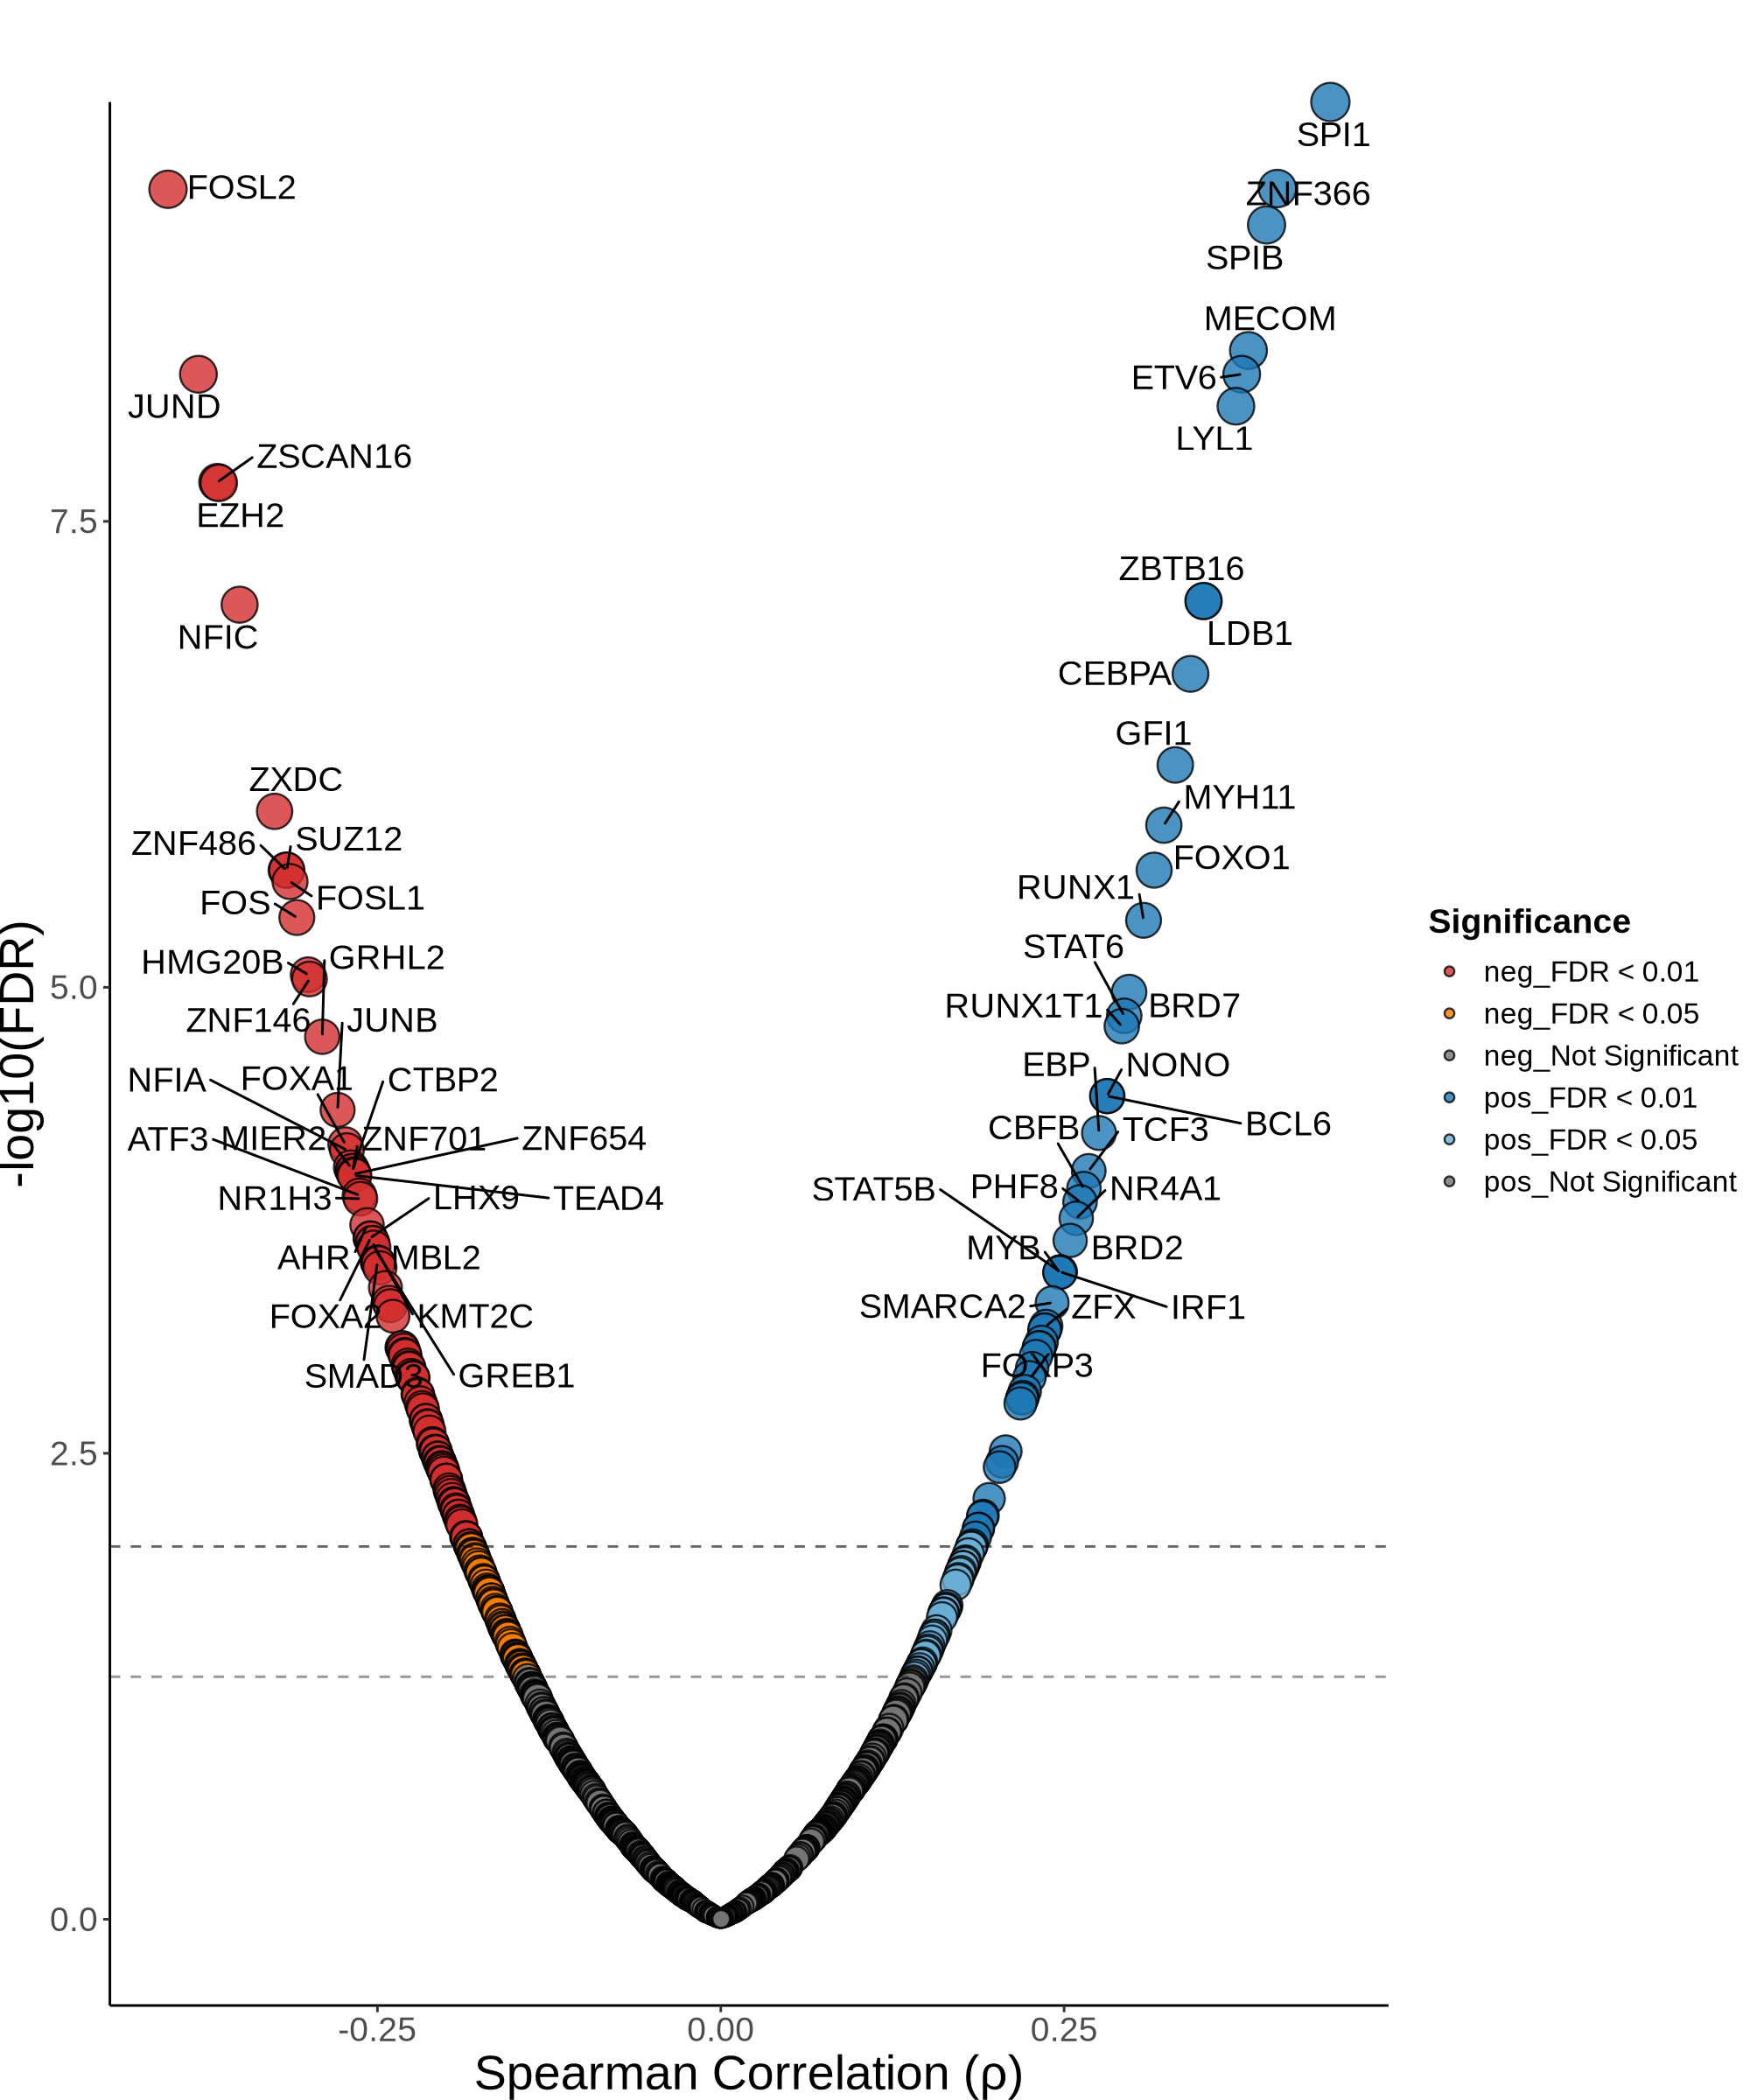

In [9]:
# 1. Volcano Plot (unchanged, still ggplot)
volcano_results_flipped <- plot_tf_volcano(
  tf_corr = pc2_corr, 
  title = "",
  top_n_pos = 30,
  top_n_neg = 30,
  flip_values = TRUE
)

options(repr.plot.width = 10, repr.plot.height = 12, repr.plot.res = 200)

print(volcano_results_flipped$plot)

# ----------------------------------------------------------------------------

In [10]:
#Volcano Plot (matched by cancer associations)
save_pc_volcanos <- function(pc_corr_list, 
                              output_dir = "../../outputs/Fig4/TF-Corr-Volcanos/",
                              top_n_pos = 30, 
                              top_n_neg = 30,
                              width = 10, 
                              height = 12, 
                              dpi = 300) {
  
  dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)
  
  for (pc_name in names(pc_corr_list)) {
    
    cat("Saving volcano for:", pc_name, "\n")
    
    results <- plot_tf_volcano(
      tf_corr     = pc_corr_list[[pc_name]],
      title       = "",
      top_n_pos   = top_n_pos,
      top_n_neg   = top_n_neg,
      flip_values = TRUE
    )
    
    ggsave(
      filename = file.path(output_dir, paste0("Fig-", pc_name, "-Volcano.png")),
      plot     = results$plot,
      width    = width,
      height   = height,
      units    = "in",
      dpi      = dpi,
      bg       = "transparent",
        create.dir = TRUE
    )
  }
  cat("Done! Saved", length(pc_corr_list), "volcano plots to", output_dir, "\n")
}

pc_corr_list <- list(
  PC2  = pc2_corr
)

save_pc_volcanos(pc_corr_list)

Saving volcano for: PC2 


Warning message:
“Removed 743 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


Done! Saved 1 volcano plots to ../../outputs/Fig4/TF-Corr-Volcanos/ 


Warning message:
“Removed 743 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


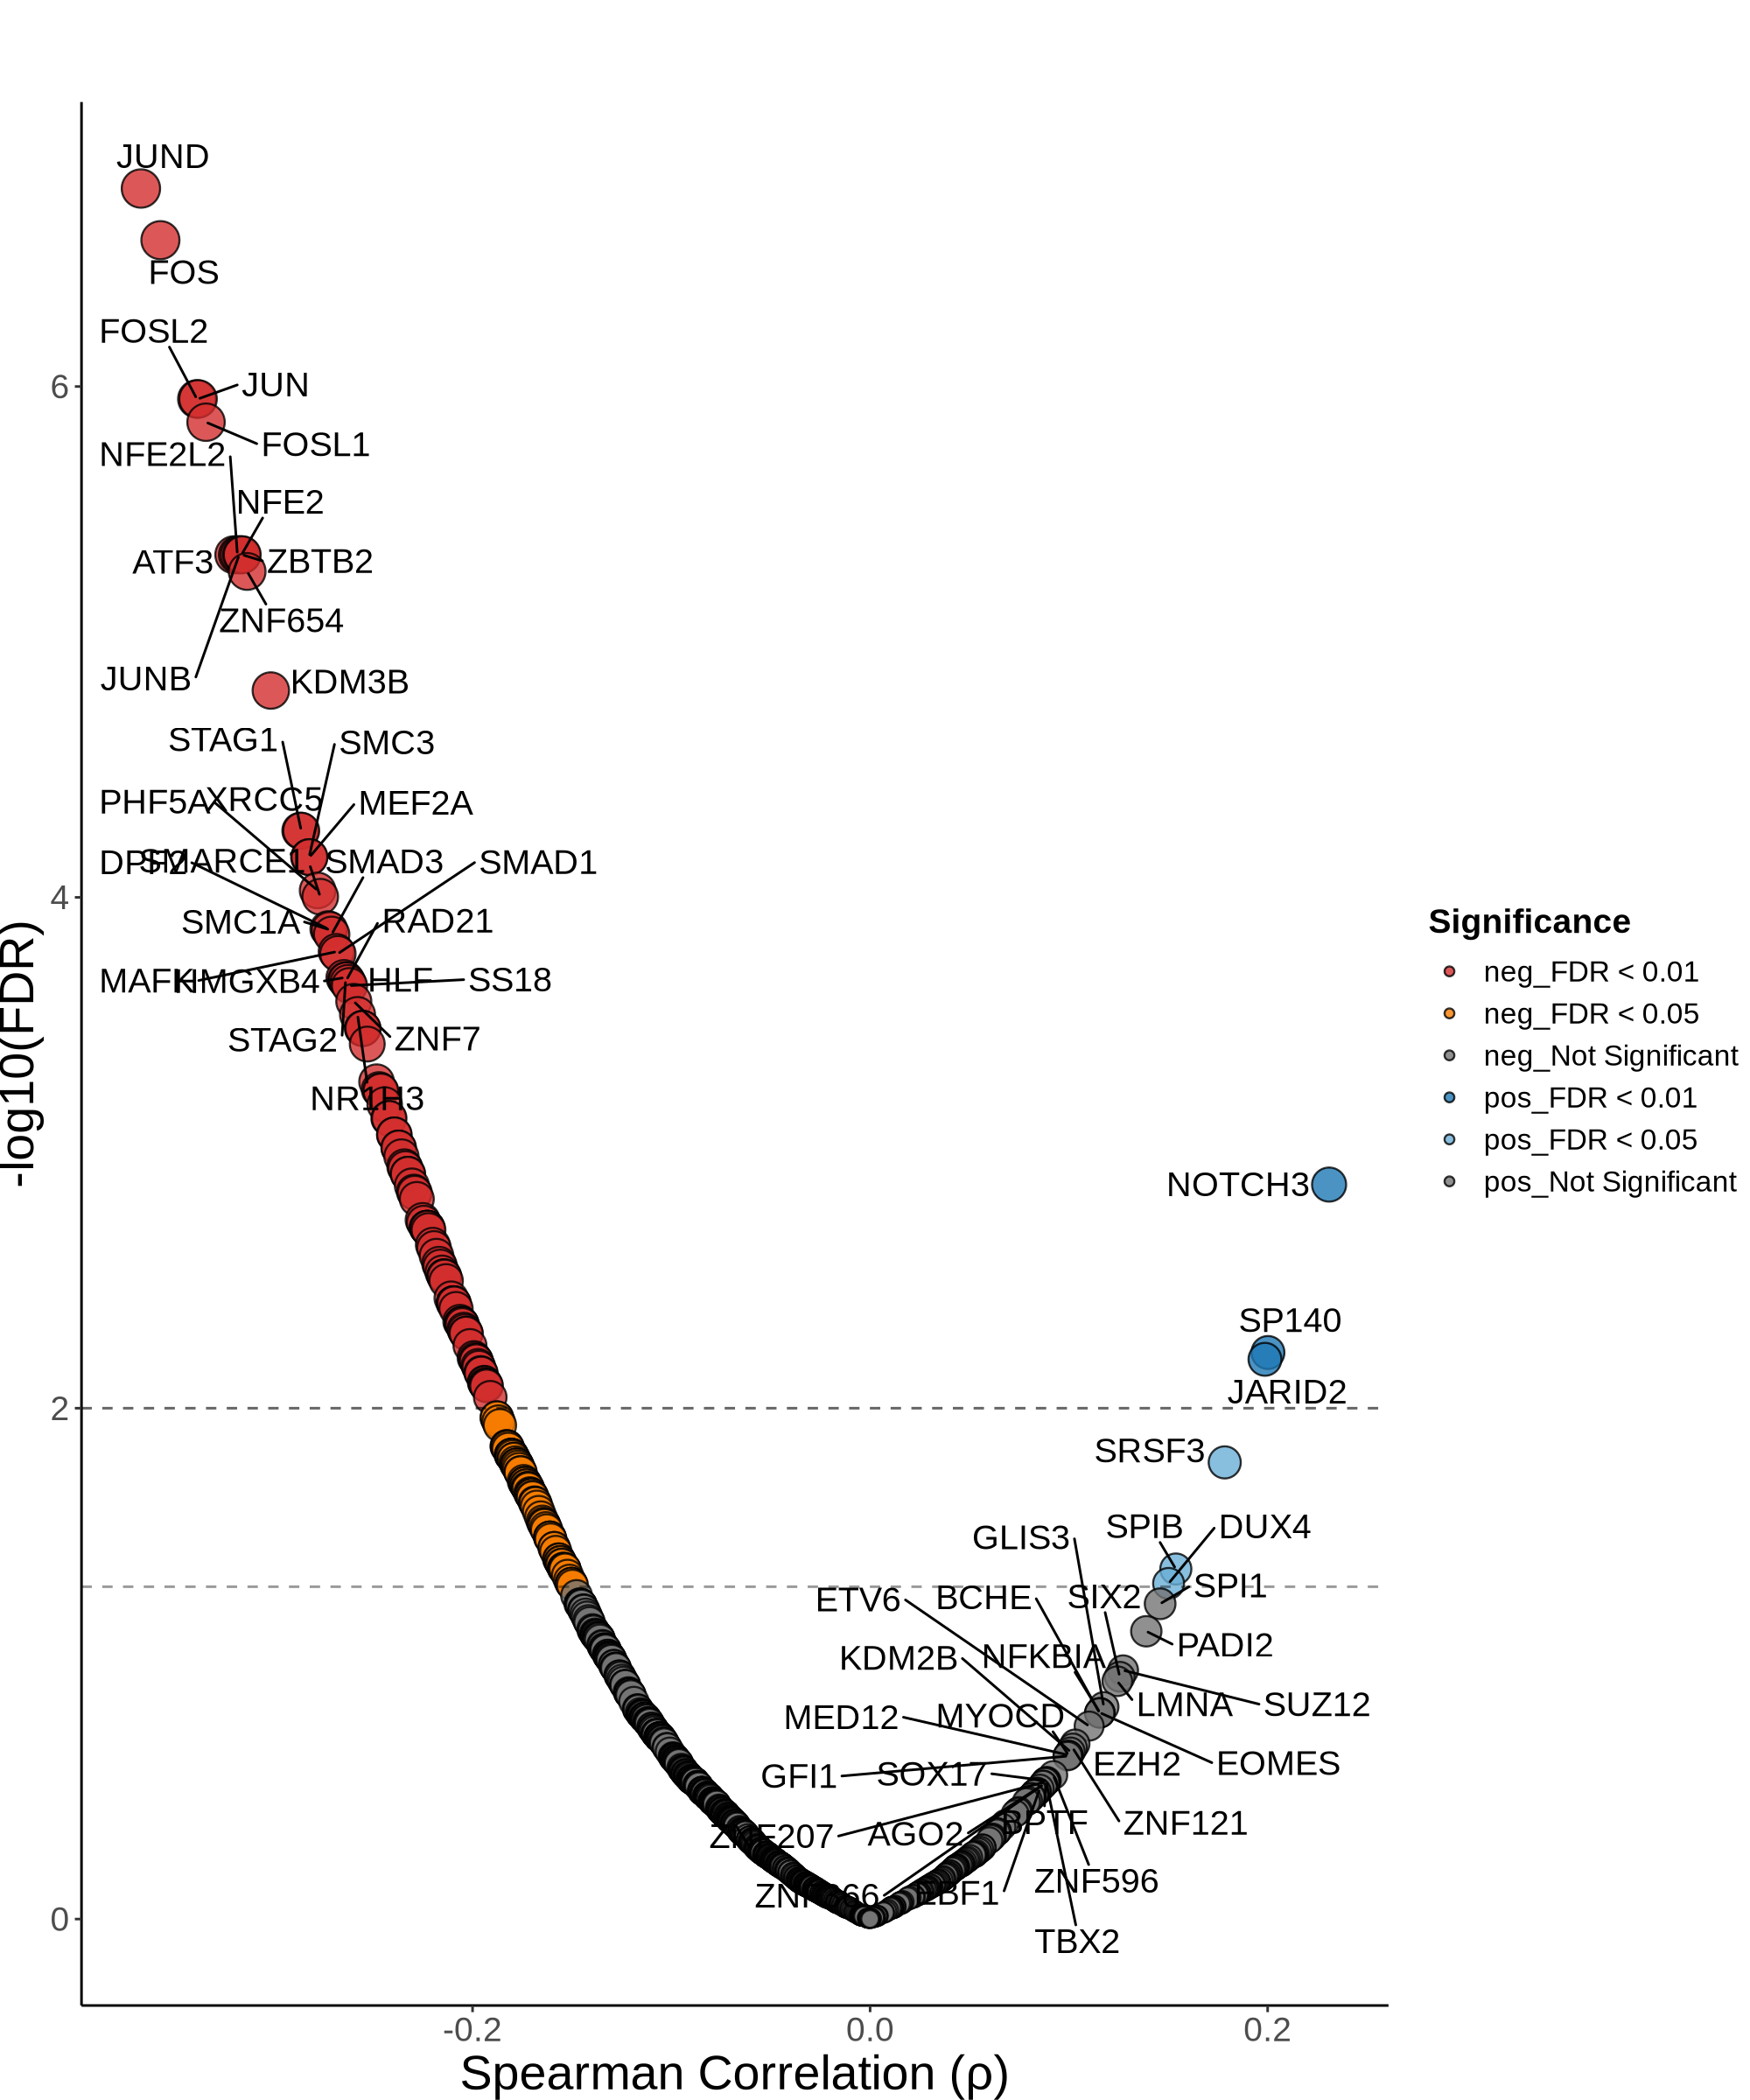

In [11]:
# 1. Volcano Plot (unchanged, still ggplot)
volcano_results_flipped <- plot_tf_volcano(
  tf_corr = pc4_corr, 
  title = "",
  top_n_pos = 30,
  top_n_neg = 30,
  flip_values = FALSE
)

options(repr.plot.width = 10, repr.plot.height = 12, repr.plot.res = 200)

print(volcano_results_flipped$plot)

# ----------------------------------------------------------------------------

In [12]:
#Volcano Plot (matched by cancer associations)
save_pc_volcanos <- function(pc_corr_list, 
                              output_dir = "../../outputs/Fig4/TF-Corr-Volcanos/",
                              top_n_pos = 30, 
                              top_n_neg = 30,
                              width = 10, 
                              height = 12, 
                              dpi = 300) {
  
  dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)
  
  for (pc_name in names(pc_corr_list)) {
    
    cat("Saving volcano for:", pc_name, "\n")
    
    results <- plot_tf_volcano(
      tf_corr     = pc_corr_list[[pc_name]],
      title       = "",
      top_n_pos   = top_n_pos,
      top_n_neg   = top_n_neg,
      flip_values = FALSE
    )
    
    ggsave(
      filename = file.path(output_dir, paste0("Fig-", pc_name, "-Volcano.png")),
      plot     = results$plot,
      width    = width,
      height   = height,
      units    = "in",
      dpi      = dpi,
      bg       = "transparent"
    )
  }
  cat("Done! Saved", length(pc_corr_list), "volcano plots to", output_dir, "\n")
}

pc_corr_list <- list(
  PC4  = pc4_corr
)

save_pc_volcanos(pc_corr_list)

Saving volcano for: PC4 


Warning message:
“Removed 743 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


Done! Saved 1 volcano plots to ../../outputs/Fig4/TF-Corr-Volcanos/ 


## Figure 4e: scATAC-seq Tissue Resolved Heatmaps

In [13]:
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(tibble)
  library(dplyr)
  library(tidyr)
})

# ============================================================
# NORMALIZATION HELPER
# ============================================================
normalize_accessibility <- function(mat,
                                    method = "row_zscore_centered_columns",
                                    params = list()) {

  mat <- as.matrix(mat)
  storage.mode(mat) <- "double"
  mat[is.infinite(mat)] <- NA

  p <- modifyList(list(
    center_minmax = TRUE,
    center_percentile = TRUE,
    mad_const = 1.4826,
    quantile_center_columns = TRUE
  ), params)

  if (method == "none") {
    out <- mat

  } else if (method == "row_zscore") {
    out <- t(scale(t(mat)))

  } else if (method == "row_zscore_centered_columns") {
    out <- t(scale(t(mat)))
    out <- sweep(out, 2, colMeans(out, na.rm = TRUE), FUN = "-")

  } else if (method == "col_zscore") {
    out <- scale(mat)

  } else if (method == "col_robust_zscore") {
    out <- mat
    for (j in seq_len(ncol(mat))) {
      x <- mat[, j]
      med <- median(x, na.rm = TRUE)
      madx <- mad(x, center = med, constant = p$mad_const, na.rm = TRUE)

      if (is.na(madx) || madx == 0) {
        sdj <- sd(x, na.rm = TRUE)
        out[, j] <- ifelse(is.na(sdj) || sdj == 0, 0, (x - med) / sdj)
      } else {
        out[, j] <- (x - med) / madx
      }
    }

  } else if (method == "col_minmax") {
    out <- mat
    for (j in seq_len(ncol(mat))) {
      x <- mat[, j]
      minx <- min(x, na.rm = TRUE)
      maxx <- max(x, na.rm = TRUE)
      if (maxx - minx == 0) out[, j] <- 0 else out[, j] <- (x - minx) / (maxx - minx)
      if (p$center_minmax) out[, j] <- out[, j] - 0.5
    }

  } else if (method == "col_percentile") {
    out <- mat
    for (j in seq_len(ncol(mat))) {
      x <- mat[, j]
      n <- sum(!is.na(x))
      if (n <= 1) {
        out[, j] <- 0
      } else {
        r <- rank(x, ties.method = "average", na.last = "keep")
        out[, j] <- (r - 1) / (n - 1)
      }
      if (p$center_percentile) out[, j] <- out[, j] - 0.5
    }

  } else if (method == "col_quantile") {
    if (!requireNamespace("preprocessCore", quietly = TRUE))
      stop("Install preprocessCore for quantile normalization.")

    mat_clean <- mat
    for (j in seq_len(ncol(mat_clean))) {
      med <- median(mat_clean[, j], na.rm = TRUE)
      mat_clean[, j][is.na(mat_clean[, j])] <- med
    }

    out <- preprocessCore::normalize.quantiles(mat_clean)
    colnames(out) <- colnames(mat)
    rownames(out) <- rownames(mat)

    if (p$quantile_center_columns) {
      out <- sweep(out, 2, colMeans(out, na.rm = TRUE), FUN = "-")
    }

  } else {
    stop("Unknown method: ", method)
  }

  out[is.na(out)] <- 0
  return(out)
}


# ============================================================
# MAIN HEATMAP FUNCTION
# ============================================================
plot_selected_tfs_complex_heatmap <- function(
  tf_list_data,
  input_dir,
  file_pattern = "^access_row_.*\\.rds$",
  cell_types_to_include = NULL,
  cell_types_to_exclude = NULL,
  column_groups = NULL,
  column_group_colors = NULL,
  neg_color = "blue",
  pos_color = "red",
  middle_color = "white",
  z_max = NULL,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  corr_col = "corr",
  normalization_method = "row_zscore_centered_columns",
  normalization_params = list(),
  tf_label_side = "right"
) {

  allowed_colors <- c("red", "purple", "blue", "green", "gold")
  neg_color <- tolower(neg_color)
  pos_color <- tolower(pos_color)

  if (!(neg_color %in% allowed_colors)) stop("neg_color must be one of: ", paste(allowed_colors, collapse = ", "))
  if (!(pos_color %in% allowed_colors)) stop("pos_color must be one of: ", paste(allowed_colors, collapse = ", "))

  color_map <- list(
    red    = "#D7301F",
    purple = "#6A51A3",
    blue   = "#2171B5",
    green  = "#1B7837",
    gold   = "#E7C000"
  )

  neg_hex <- color_map[[neg_color]]
  pos_hex <- color_map[[pos_color]]

  tf_label_side <- tolower(tf_label_side)
  if (!tf_label_side %in% c("left", "right")) stop("tf_label_side must be 'left' or 'right'")
  row_dend_side <- ifelse(tf_label_side == "left", "right", "left")

  # ------------------------------------------------------------
  # LOAD ACCESSIBILITY MATRICES
  # ------------------------------------------------------------
  file_paths <- list.files(input_dir, file_pattern, full.names = TRUE)
  if (length(file_paths) == 0) stop("No .rds files found!")

  list_of_dfs <- list()
  for (path in file_paths) {
    cell_type <- gsub("access_row_(.*)\\.rds$", "\\1", basename(path))
    tf_scores <- tryCatch(readRDS(path), error = function(e) NULL)

    if (is.null(tf_scores) || length(tf_scores) == 0) next

    temp_df <- enframe(tf_scores, name = "TF", value = "Score") %>%
      mutate(CellType = cell_type)

    list_of_dfs[[cell_type]] <- temp_df
  }

  accessibility_matrix <- bind_rows(list_of_dfs) %>%
    pivot_wider(names_from = CellType, values_from = Score, values_fill = 0) %>%
    column_to_rownames("TF") %>%
    as.matrix()

  # --- STRICT CELL TYPE MATCHING WITH EXCLUSIONS ---
  if (!is.null(cell_types_to_include)) {
    matched_types <- unlist(lapply(cell_types_to_include, function(pattern) {
      pat <- gsub("_", "\\\\_", pattern)
      grep(
        paste0("(^|_)", pat, "$"),
        colnames(accessibility_matrix),
        ignore.case = TRUE,
        value = TRUE
      )
    }))

    matched_types <- unique(matched_types)

    if (!is.null(cell_types_to_exclude)) {
      for (ex in cell_types_to_exclude) {
        matched_types <- matched_types[!grepl(ex, matched_types, ignore.case = TRUE)]
      }
    }

    if (length(matched_types) == 0) {
      stop("After exclusion, no cell types remain.")
    }

    accessibility_matrix <- accessibility_matrix[, matched_types, drop = FALSE]
    message("Matched cell types: ", paste(matched_types, collapse = ", "))
  }

  # ------------------------------------------------------------
  # SUBSET TFs
  # ------------------------------------------------------------
  tfs_for_heatmap <- tf_list_data$tf_clean
  valid_tfs <- intersect(rownames(accessibility_matrix), tfs_for_heatmap)
  accessibility_matrix <- accessibility_matrix[valid_tfs, , drop = FALSE]
  tf_list_data_valid <- tf_list_data %>% filter(tf_clean %in% valid_tfs)

  # ------------------------------------------------------------
  # NORMALIZE
  # ------------------------------------------------------------
  scaled_matrix <- normalize_accessibility(accessibility_matrix,
                                           method = normalization_method,
                                           params = normalization_params)

  # ------------------------------------------------------------
  # SPLITS
  # ------------------------------------------------------------
  row_split <- ifelse(tf_list_data_valid$side == "pos",
                      "A_Positive Correlation",
                      "B_Negative Correlation")
  row_split <- factor(row_split, levels = c("A_Positive Correlation", "B_Negative Correlation"))

  ordered_tfs <- tf_list_data_valid$tf_clean
  if (!cluster_rows) {
    df_pos <- tf_list_data_valid %>% filter(side == "pos") %>% arrange(desc(.data[[corr_col]]))
    df_neg <- tf_list_data_valid %>% filter(side == "neg") %>% arrange(.data[[corr_col]])
    ordered_tfs <- c(df_pos$tf_clean, df_neg$tf_clean)

    row_split <- c(
      rep("A_Positive Correlation", nrow(df_pos)),
      rep("B_Negative Correlation", nrow(df_neg))
    )
    row_split <- factor(row_split, levels = c("A_Positive Correlation", "B_Negative Correlation"))
  }

  scaled_matrix <- scaled_matrix[ordered_tfs, , drop = FALSE]

    # ------------------------------------------------------------
    # COLUMN GROUPING AND ORDERING
    # ------------------------------------------------------------
    col_split <- NULL
    bottom_annotation <- NULL
    
    if (!is.null(column_groups)) {
      
      # Get all column names
      all_cols <- colnames(scaled_matrix)
      
      # Create mapping from cell type to group (case-insensitive)
      cell_type_to_group <- setNames(rep(NA_character_, length(all_cols)), all_cols)
      group_order <- names(column_groups)
      
      for (group_name in group_order) {
        for (ct in column_groups[[group_name]]) {
          # Create pattern - escape special regex chars and handle underscores
          ct_pattern <- gsub(" ", "_", ct)
          ct_pattern <- gsub("([.])", "\\\\\\1", ct_pattern)  # escape dots
          
          # Find matching columns (case-insensitive)
          for (col in all_cols) {
            if (grepl(paste0("(^|_)", ct_pattern, "$"), col, ignore.case = TRUE)) {
              if (is.na(cell_type_to_group[col])) {  # Only assign if not already assigned
                cell_type_to_group[col] <- group_name
              }
            }
          }
        }
      }
      
      # Check for unassigned columns
      unassigned <- names(cell_type_to_group[is.na(cell_type_to_group)])
      if (length(unassigned) > 0) {
        message("WARNING - Unassigned cell types: ", paste(unassigned, collapse = ", "))
        message("These must be added to column_groups or they will cause an error.")
        # Assign to "Other" group
        cell_type_to_group[unassigned] <- "Other"
        if (!"Other" %in% group_order) {
          group_order <- c(group_order, "Other")
        }
      }
      
      # Create factor for column split
      col_split <- factor(cell_type_to_group, levels = group_order)
      names(col_split) <- all_cols
      
      # Reorder columns by group
      new_col_order <- c()
      for (grp in group_order) {
        cols_in_group <- all_cols[cell_type_to_group == grp]
        if (length(cols_in_group) == 0) next
        
        # Optionally cluster within group
        if (cluster_columns && length(cols_in_group) > 1) {
          sub_mat <- scaled_matrix[, cols_in_group, drop = FALSE]
          hc <- hclust(dist(t(sub_mat)))
          cols_in_group <- cols_in_group[hc$order]
        }
        new_col_order <- c(new_col_order, cols_in_group)
      }
      
      # Verify all columns are accounted for
      message("Total columns: ", length(all_cols))
      message("Columns in new order: ", length(new_col_order))
      
      if (length(new_col_order) != length(all_cols)) {
        stop("Column mismatch! Missing: ", 
             paste(setdiff(all_cols, new_col_order), collapse = ", "))
      }
      
      scaled_matrix <- scaled_matrix[, new_col_order, drop = FALSE]
      col_split <- col_split[new_col_order]
      
      # Default colors if not provided
      if (is.null(column_group_colors)) {
        default_colors <- c("#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", 
                            "#FF7F00", "#A65628", "#F781BF", "#999999")
        column_group_colors <- setNames(
          default_colors[1:length(group_order)],
          group_order
        )
      } else {
        # Make sure "Other" has a color if it exists
        if ("Other" %in% group_order && !"Other" %in% names(column_group_colors)) {
          column_group_colors["Other"] <- "#999999"
        }
      }
      
      # Create bottom annotation bar
      bottom_annotation <- HeatmapAnnotation(
        Group = col_split,
        col = list(Group = column_group_colors),
        which = "column",
        show_legend = TRUE,
        show_annotation_name = FALSE,
        annotation_legend_param = list(
          Group = list(
            title = "Cell Type Category",
            title_gp = gpar(fontsize = 14),
            labels_gp = gpar(fontsize = 12),
            grid_height = unit(5, "mm"),
            grid_width = unit(5, "mm")
          )
        )
      )
      
    } else if (cluster_columns && ncol(scaled_matrix) > 1) {
      col_order <- hclust(dist(t(scaled_matrix)))$order
      ordered_cell_types <- colnames(scaled_matrix)[col_order]
      scaled_matrix <- scaled_matrix[, ordered_cell_types, drop = FALSE]
    }

  # ------------------------------------------------------------
  # MAKE COLUMN NAMES PRETTY: replace "_" → " "
  # ------------------------------------------------------------
  colnames(scaled_matrix) <- gsub("_", " ", colnames(scaled_matrix))

  # ------------------------------------------------------------
  # COLOR SCALE
  # ------------------------------------------------------------
  if (is.null(z_max)) {
    z_max <- max(abs(scaled_matrix), na.rm = TRUE)
    if (!is.finite(z_max) || z_max <= 0) z_max <- 1
  }

  col_fun <- circlize::colorRamp2(
    c(-z_max, 0, z_max),
    c(neg_hex, middle_color, pos_hex)
  )

  legend_breaks <- seq(-z_max, z_max, length.out = 5)
  legend_labels <- sprintf("%.2f", legend_breaks)

  # ------------------------------------------------------------
  # HEATMAP
  # ------------------------------------------------------------
  ht <- Heatmap(
    scaled_matrix,
    name = "Normalized",
    col = col_fun,
    cluster_rows = cluster_rows,
    cluster_row_slices = FALSE,
    cluster_columns = FALSE,  # We handle ordering manually when groups are specified
    
    # Column splitting for groups
    column_split = col_split,
    column_gap = unit(3, "mm"),
    column_title_gp = gpar(fontsize = 0),  # Hide individual group titles on top
    
    # Bottom annotation for group color bar
    bottom_annotation = bottom_annotation,

    # Row grouping
    row_split = row_split,
    row_title = c("Top Positive Corr.", "Top Negative Corr."),
    row_title_side = tf_label_side,
    row_title_rot = 90,
    row_title_gp = grid::gpar(fontsize = 16),
    row_gap = unit(6, "mm"),

    row_names_side = tf_label_side,
    row_dend_side = row_dend_side,
    column_names_side = "bottom",
    row_names_gp = gpar(fontsize = 14),
    column_names_gp = gpar(fontsize = 16),
    column_names_rot = 90,
    column_names_max_height = unit(8, "cm"),
    rect_gp = gpar(col = "black", lwd = 0.5),
    heatmap_legend_param = list(
      title = "Normalized ATAC Accessibility",
      legend_direction = "vertical",
      title_position = "leftcenter-rot",
      at = legend_breaks,
      labels = legend_labels,
      border = "black",
      grid_height = unit(20, "mm"),
      grid_width = unit(6, "mm"),
      legend_height = unit(50, "mm"),
      labels_gp = gpar(fontsize = 12),
      title_gp = gpar(fontsize = 14)
    )
  )

  return(ht)
}

Matched cell types: Immune, Erythroid, Hepatocyte, Endothelial, Adult_Stromal, Follicular, Pulm_Epithelial, LUAD, LUSC

Total columns: 9

Columns in new order: 9



pdf 
  2 

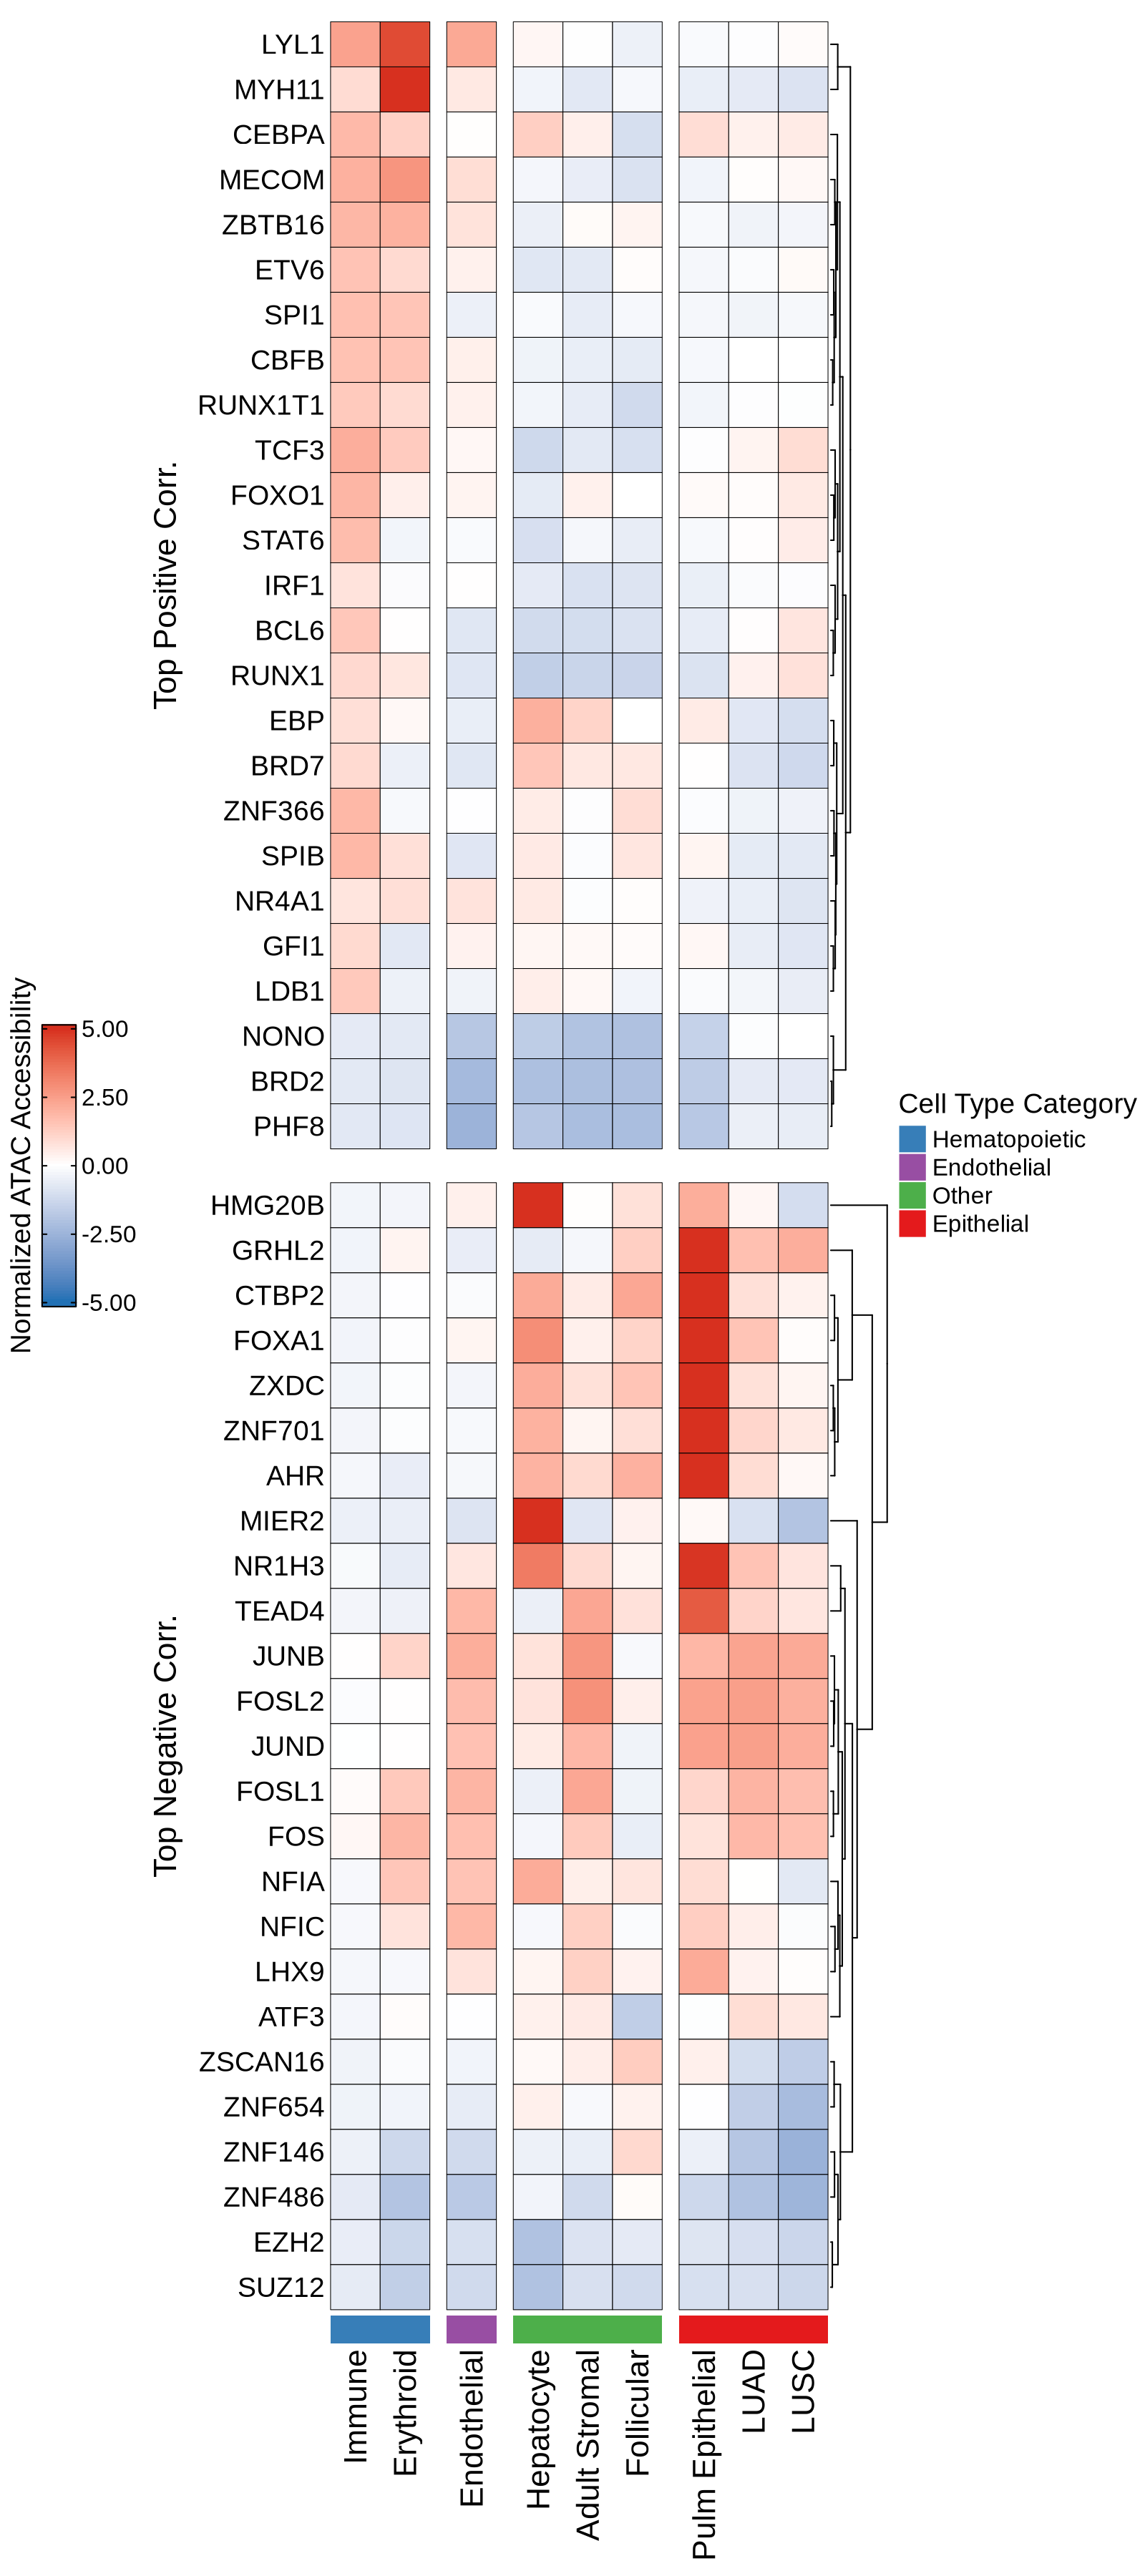

In [14]:
ordered_tf_data <- get_ordered_tfs(
  tf_corr_data = pc2_corr, 
  top_n_pos = 25, 
  top_n_neg = 25
)

ordered_tf_data <- ordered_tf_data %>%
  mutate(correlation = -correlation,
         side = ifelse(side == "pos", "neg", "pos"))

# Define column groups (order matters - this is left to right order)
column_groups <- list(
  "Hematopoietic" = c("Immune", "Erythroid"),
  "Endothelial" = c("Endothelial"),
      "Other" = c("Hepatocyte", "Skeletal_Myocyte", "Adult_Stromal", "Follicular"),
    "Epithelial" = c("Pulm_Epithelial", "LUAD", "LUSC")
)


# Define colors for each group (optional - defaults will be used if not provided)
column_group_colors <- c(
  "Hematopoietic" = "#377EB8",
  "Endothelial" = "#984EA3", 
  "Other" = "#4DAF4A",
  "Epithelial" = "#E41A1C"
)


input_dir <- "../..//methods_code/WG/results/ATAC_matrix"

options(repr.plot.width = 8, repr.plot.height = 18, repr.plot.res = 200)


ht <- plot_selected_tfs_complex_heatmap(
  tf_list_data = ordered_tf_data,
  input_dir = input_dir,
  cell_types_to_include = c("Immune", "Erythroid", "Hepatocyte", 
                            "Endothelial", "Adult_Stromal", "Follicular", 
                            "Pulm_Epithelial", "LUAD", "LUSC"),
  cell_types_to_exclude = c("Fetal_Neuronal_Glial"),
  column_groups = column_groups,
  column_group_colors = column_group_colors,
  neg_color = "blue",
  pos_color = "red",
  z_max = 5,
  cluster_rows = TRUE,
  cluster_columns = FALSE,
  corr_col = "correlation",
  normalization_method = "col_robust_zscore",
  normalization_params = list(mad_const = 1.4826),
  tf_label_side = "left"
)

grid::grid.newpage()
ComplexHeatmap::draw(ht, heatmap_legend_side = "left")

png("../../outputs/Fig4/Fig-PC2-ATAC-Heatmap.png", width = 8, height = 18, units = "in", res = 500)
ComplexHeatmap::draw(ht, heatmap_legend_side = "left")
dev.off()

Matched cell types: Immune, Erythroid, Hepatocyte, Endothelial, Adult_Stromal, Follicular, Pulm_Epithelial, LUAD, LUSC

Total columns: 9

Columns in new order: 9



pdf 
  2 

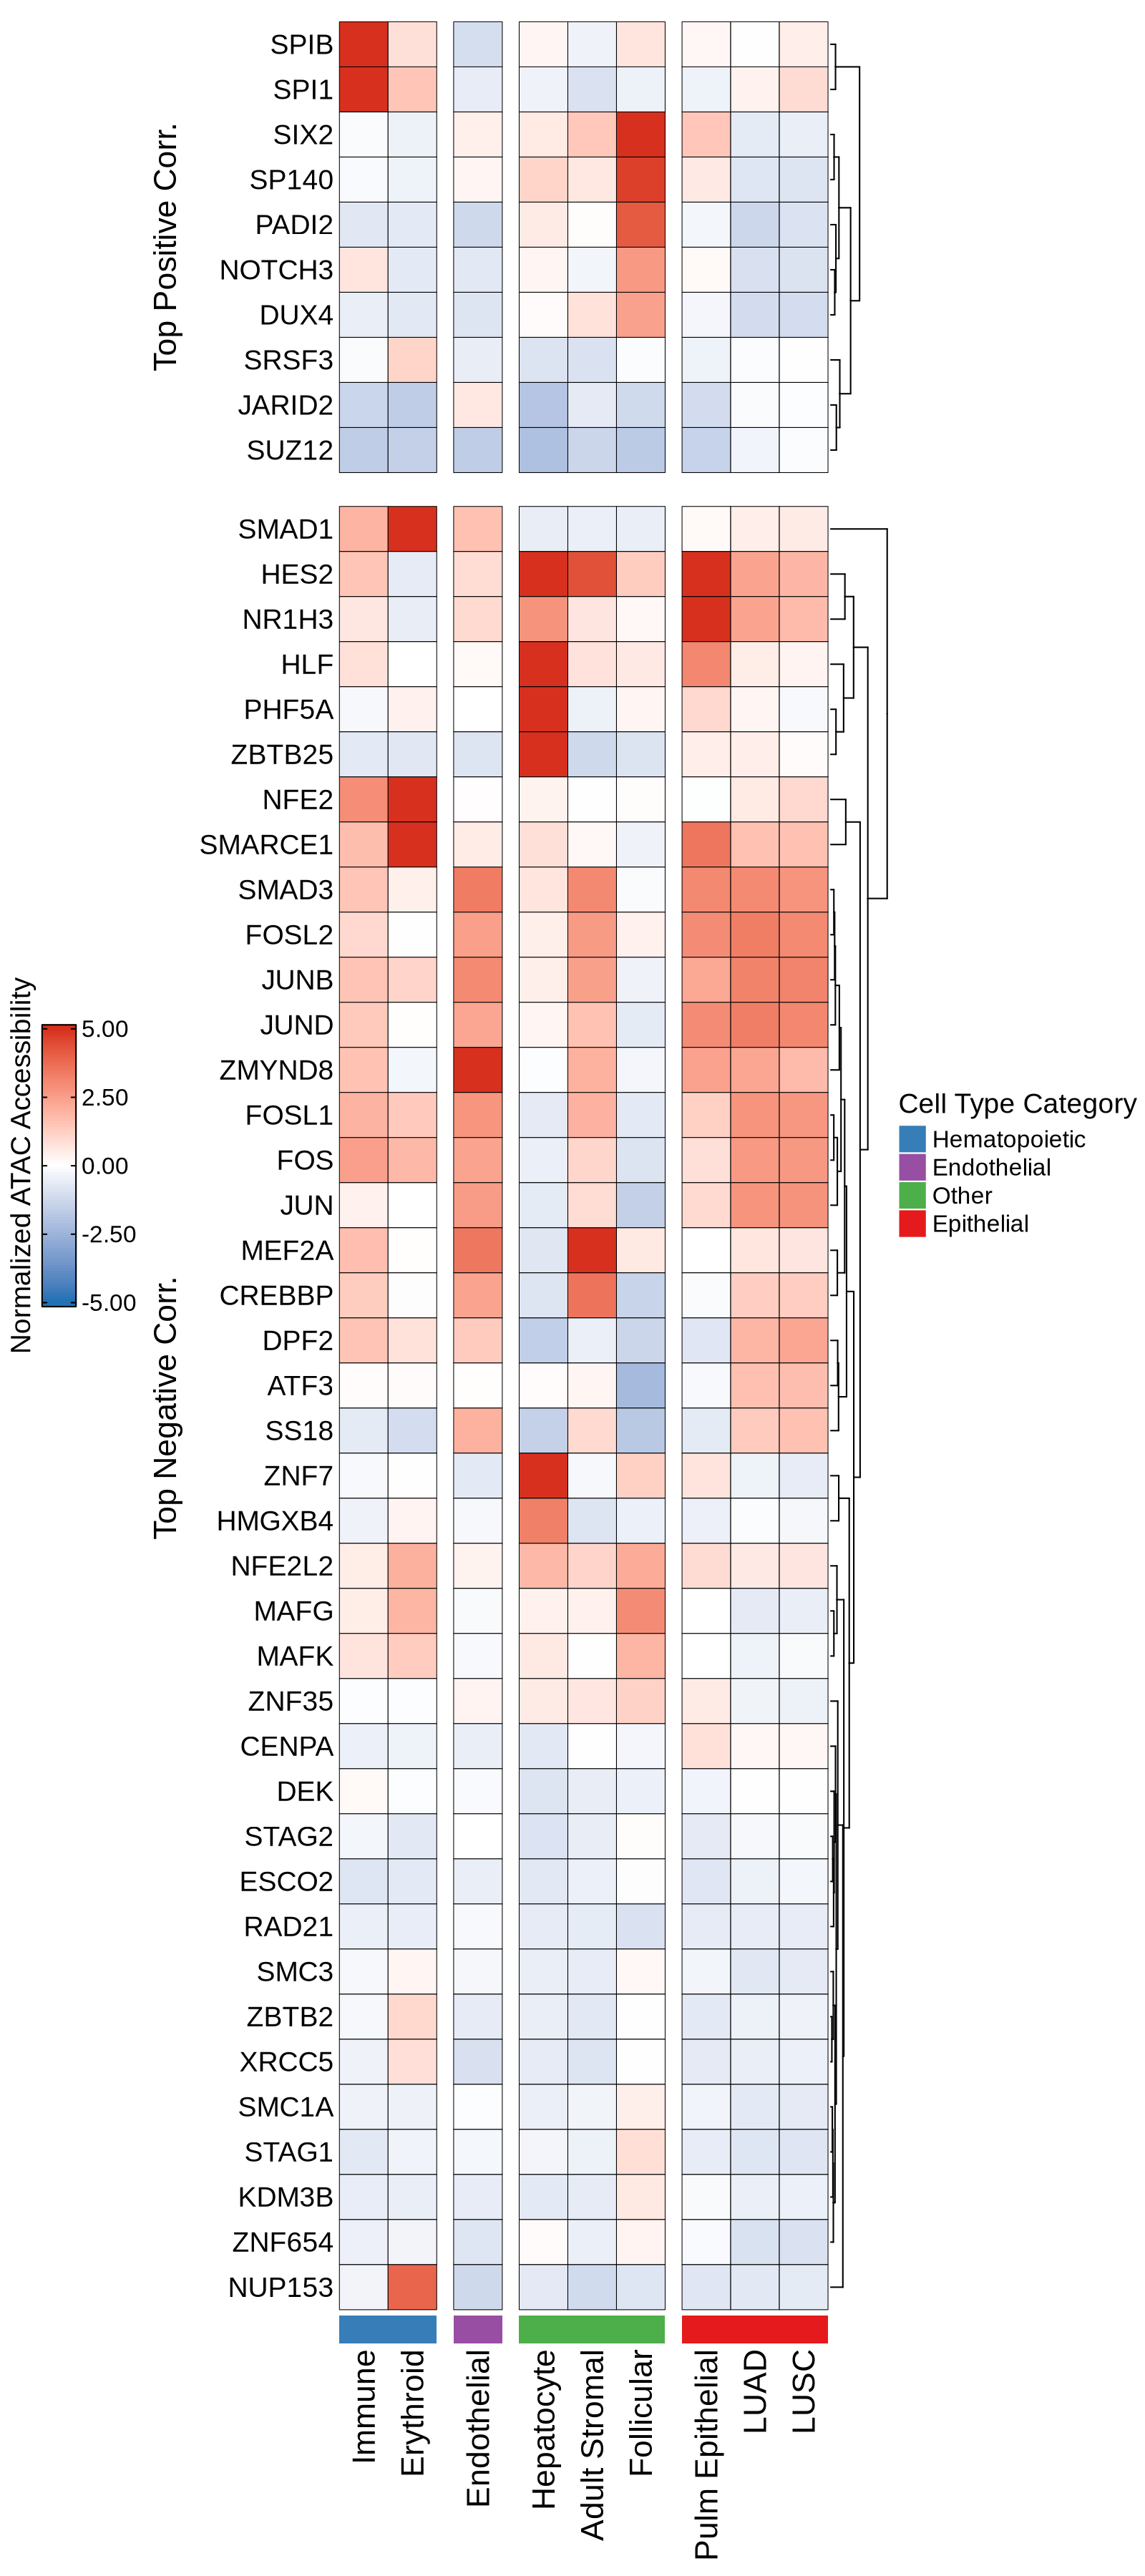

In [15]:
ordered_tf_data <- get_ordered_tfs(
  tf_corr_data = pc4_corr, 
  top_n_pos = 10, 
  top_n_neg = 40
)

input_dir <- "../../methods_code/WG/results/ATAC_matrix"

options(repr.plot.width = 8, repr.plot.height = 18, repr.plot.res = 200)


ht <- plot_selected_tfs_complex_heatmap(
  tf_list_data = ordered_tf_data,
  input_dir = input_dir,
  cell_types_to_include = c("Immune", "Erythroid", "Hepatocyte", 
                            "Endothelial", "Adult_Stromal", "Follicular", 
                            "Pulm_Epithelial", "LUAD", "LUSC"),
  cell_types_to_exclude = c("Fetal_Neuronal_Glial"),
  column_groups = column_groups,
  column_group_colors = column_group_colors,
  neg_color = "blue",
  pos_color = "red",
  z_max = 5,
  cluster_rows = TRUE,
  cluster_columns = FALSE,
  corr_col = "correlation",
  normalization_method = "col_robust_zscore",
  normalization_params = list(mad_const = 1.4826),
  tf_label_side = "left"
)

grid::grid.newpage()
ComplexHeatmap::draw(ht, heatmap_legend_side = "left")

png("../../outputs/Fig4/Fig-PC4-ATAC-Heatmap.png", width = 8, height = 18, units = "in", res = 500)
ComplexHeatmap::draw(ht, heatmap_legend_side = "left")
dev.off()

## Figure 4e,f: GSEA

In [16]:
###############################################################################
# FINAL PIPELINE — JOIN FDR + TF-TARGET GSEA + FIGURES
# VERSION: All significant TFs with optional axis filter (pos/neg/all)
###############################################################################

suppressPackageStartupMessages({
  library(dplyr)
  library(stringr)
  library(clusterProfiler)
  library(org.Hs.eg.db)
  library(dorothea)
  library(enrichplot)
  library(ggplot2)
})


###############################################################################
# 0. FUNCTION: Build geneList from TF→target weighted scores
###############################################################################

make_geneList_from_tfs <- function(tf_sub, regulon, OrgDb) {

  tf_targets <- regulon %>%
    inner_join(tf_sub, by = c("tf" = "tf_clean"))

  gene_scores <- tf_targets %>%
    mutate(weighted = correlation * mor) %>%
    group_by(target) %>%
    summarise(score = sum(weighted, na.rm = TRUE), .groups = "drop")

  gene_map <- bitr(
    gene_scores$target,
    fromType = "SYMBOL",
    toType   = "ENTREZID",
    OrgDb    = OrgDb
  )

  gene_scores_mapped <- gene_scores %>%
    inner_join(gene_map, by = c("target" = "SYMBOL"))

  geneList <- gene_scores_mapped$score
  names(geneList) <- gene_scores_mapped$ENTREZID

  sort(geneList, decreasing = TRUE)
}


###############################################################################
# 1. MAIN FUNCTION FOR FIGURES
###############################################################################

run_pc_figures_tfGSEA <- function(ordered_tf_data, pc_corr, PC_name = "PC", 
                                   axis = "all", flip_correlations = FALSE) {

  ##########################################################################
  # Validate axis parameter
  ##########################################################################

  if (!axis %in% c("all", "pos", "neg")) {
    stop("axis must be one of: 'all', 'pos', or 'neg'")
  }

  ##########################################################################
  # STEP A — Join FDR-adjusted p-values from pc_corr into ordered_tf_data
  ##########################################################################

  pc_clean <- pc_corr %>%
    mutate(tf_clean = tf %>%
             sub("^.+/tf_", "", .) %>%
             sub("_5k_rel_cov_profile$", "", .))

  merged <- ordered_tf_data %>%
    left_join(pc_clean %>% dplyr::select(tf_clean, fdr), by = "tf_clean")

  # Check for unmatched TFs
  n_missing <- sum(is.na(merged$fdr))
  if (n_missing > 0) warning(n_missing, " TFs had no matching FDR value after join — check tf_clean name formatting")

  ##########################################################################
  # STEP A2 — Optionally flip correlation signs
  ##########################################################################

  if (flip_correlations) {
    cat("Flipping correlation signs: positive ↔ negative\n")
    merged <- merged %>%
      mutate(
        correlation = -correlation,
        side        = ifelse(side == "pos", "neg", "pos")
      )
  }

  ##########################################################################
  # STEP B — Filter by FDR < 0.001 and optionally by axis
  ##########################################################################

  tf_sig <- merged %>% filter(fdr < 0.001)

  if (nrow(tf_sig) == 0) stop("No TFs passed FDR < 0.0011 threshold for ", PC_name)
  cat("TFs passing FDR < 0.001:", nrow(tf_sig), "\n")

  if (axis == "pos") {
    tf_sig <- tf_sig %>% filter(side == "pos")
    axis_label <- "Positive Axis"
  } else if (axis == "neg") {
    tf_sig <- tf_sig %>% filter(side == "neg")
    axis_label <- "Negative Axis"
  } else {
    axis_label <- "All Significant"
  }

  cat("TFs after axis filter (", axis, "):", nrow(tf_sig), "\n")
  tf_sig <- tf_sig %>% dplyr::select(tf_clean, correlation)

  ##########################################################################
  # STEP C — Load DoRothEA regulon
  ##########################################################################

  data(dorothea_hs, package = "dorothea")
  regulon <- dorothea_hs %>% filter(confidence %in% c("A", "B", "C"))

  ##########################################################################
  # STEP D — Build geneList for GSEA
  ##########################################################################

  geneList <- make_geneList_from_tfs(tf_sig, regulon, org.Hs.eg.db)

  ##########################################################################
  # STEP E — Run GSEA (GO Biological Process)
  ##########################################################################

  gsea_res <- gseGO(
    geneList     = geneList,
    OrgDb        = org.Hs.eg.db,
    keyType      = "ENTREZID",
    ont          = "BP",
    minGSSize    = 20,
    pvalueCutoff = 0.3,
    seed         = TRUE,
    verbose      = FALSE
  )

  ##########################################################################
  # STEP F — FIGURE: dotplot of top enriched terms
  ##########################################################################

  fig2C <- dotplot(gsea_res, showCategory = 20) +
    ggtitle(paste0("Top Enriched GO Terms (", PC_name, " - ", axis_label,
                   if (flip_correlations) " [flipped]" else "", ")")) +
    theme(plot.title = element_text(size = 18, face = "bold", hjust = 0.5))

  ##########################################################################
  # STEP G — FIGURE: running enrichment curve for top term
  ##########################################################################

  make_running <- function(gsea_res) {
    df <- as.data.frame(gsea_res)

    if (nrow(df) == 0) {
      message("No significant GSEA results found")
      return(ggplot() + theme_void() + ggtitle("No significant GSEA results"))
    }

    topID <- df$ID[1]

    gseaplot2(
      gsea_res,
      geneSetID = topID,
      title     = paste0(tools::toTitleCase(df$Description[1]),
                         "\nAdj p = ", signif(df$p.adjust[1], 3)),
      ES_geom   = "line",
      color     = "red"
    )
  }

  fig2D <- make_running(gsea_res)

  ##########################################################################
  # RETURN RESULTS
  ##########################################################################

  return(list(
    gsea_res           = gsea_res,
    tf_significant     = tf_sig,
    geneList           = geneList,
    axis_used          = axis,
    flip_correlations  = flip_correlations,
    fig2C              = fig2C,
    fig2D              = fig2D
  ))
}




Flipping correlation signs: positive ↔ negative
TFs passing FDR < 0.001: 79 
TFs after axis filter ( neg ): 43 


'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(gene_scores$target, fromType = "SYMBOL", toType = "ENTREZID", :
“0.36% of input gene IDs are fail to map...”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (82.31% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


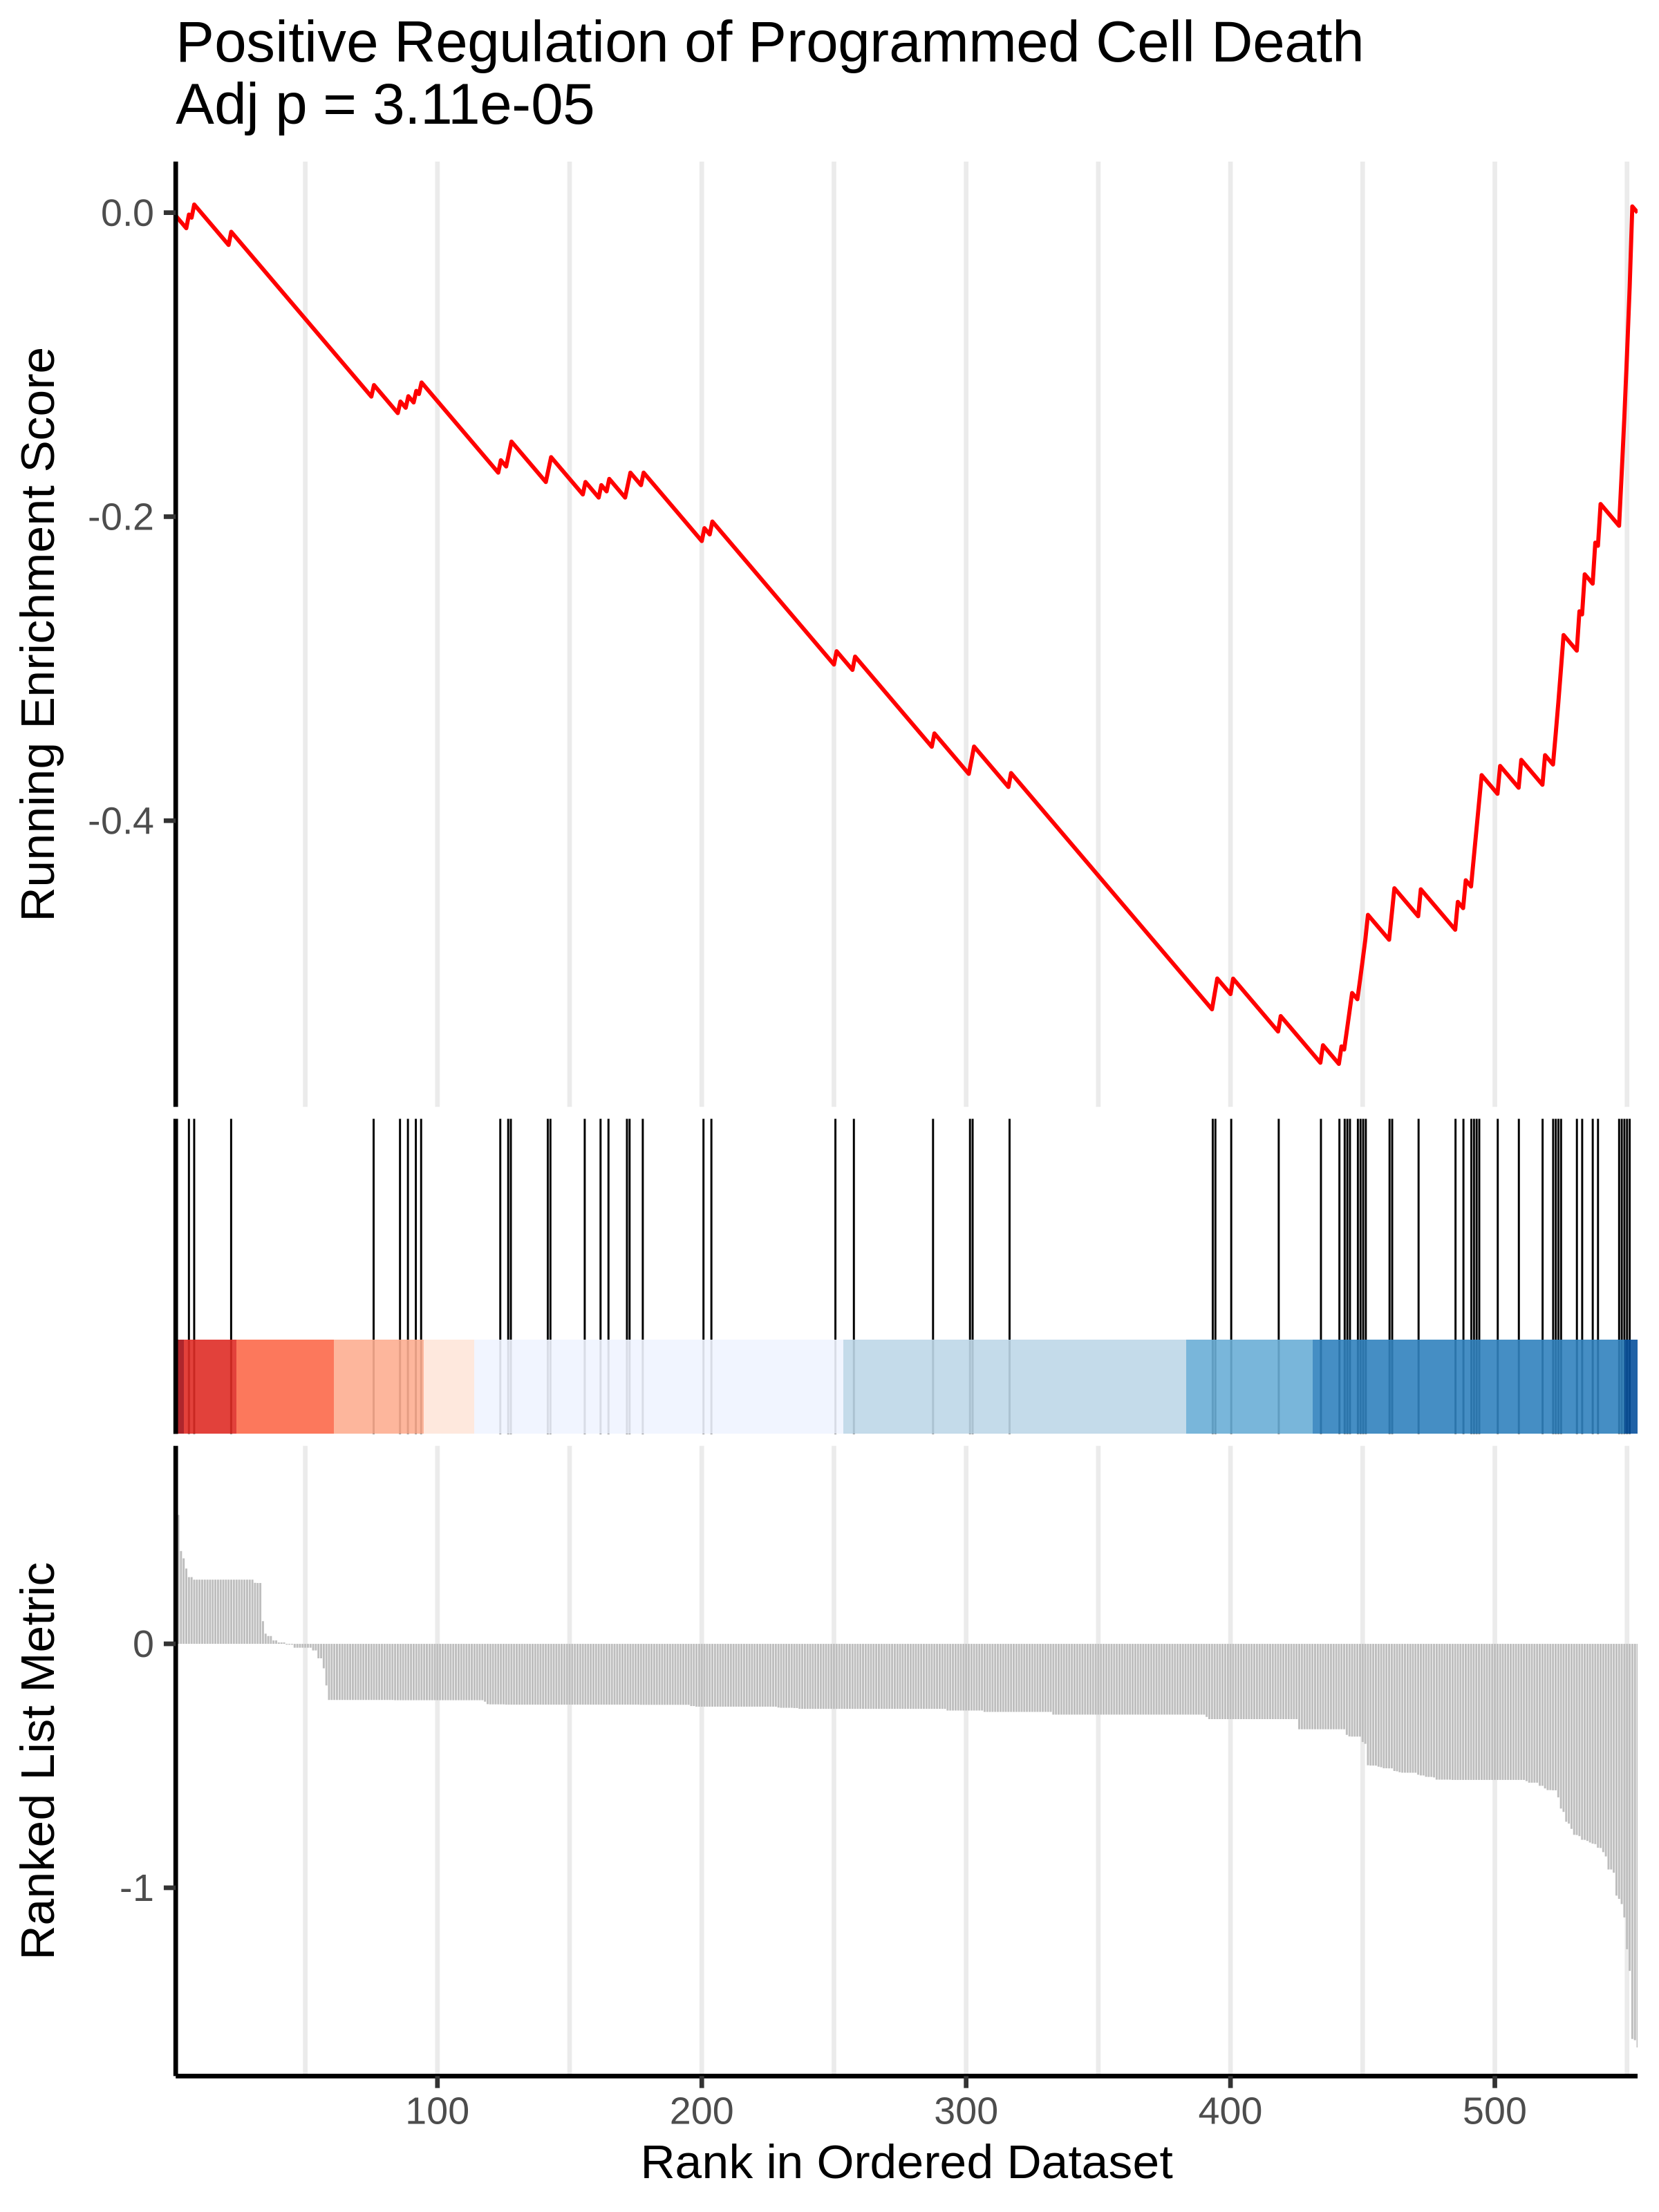

In [17]:
options(repr.plot.width = 12, repr.plot.height = 16, repr.plot.res = 200)

ordered_tf_data <- get_ordered_tfs(
  tf_corr_data = pc2_corr,
  top_n_pos    = 803,
  top_n_neg    = 803
)

set.seed(1234)
results_PC2 <- run_pc_figures_tfGSEA(
  ordered_tf_data    = ordered_tf_data,
  pc_corr            = pc2_corr,
  PC_name            = "PC2",
  axis               = "neg",
  flip_correlations  = TRUE  # set to TRUE to flip signs
)


# Get the data frame to extract info
df <- as.data.frame(results_PC2$gsea_res)

# Replot with larger, capitalized title
PC2_updated <- gseaplot2(
  results_PC2$gsea_res,
  geneSetID = df$ID[1],
  title = paste0(tools::toTitleCase(df$Description[1]),
                 "\nAdj p = ", signif(df$p.adjust[1], 3)),
  ES_geom = "line", color = "red",
  base_size = 25  # increases overall text size including title
)

PC2_updated



In [18]:
ggsave("../../outputs/Fig4/Fig-TF-GSEA-PC2-Running_enrichment.png", PC2_updated, width = 12, height = 12, dpi = 600, create.dir = TRUE)

TFs passing FDR < 0.001: 45 
TFs after axis filter ( neg ): 45 


'select()' returned 1:many mapping between keys and columns

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (80.55% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”


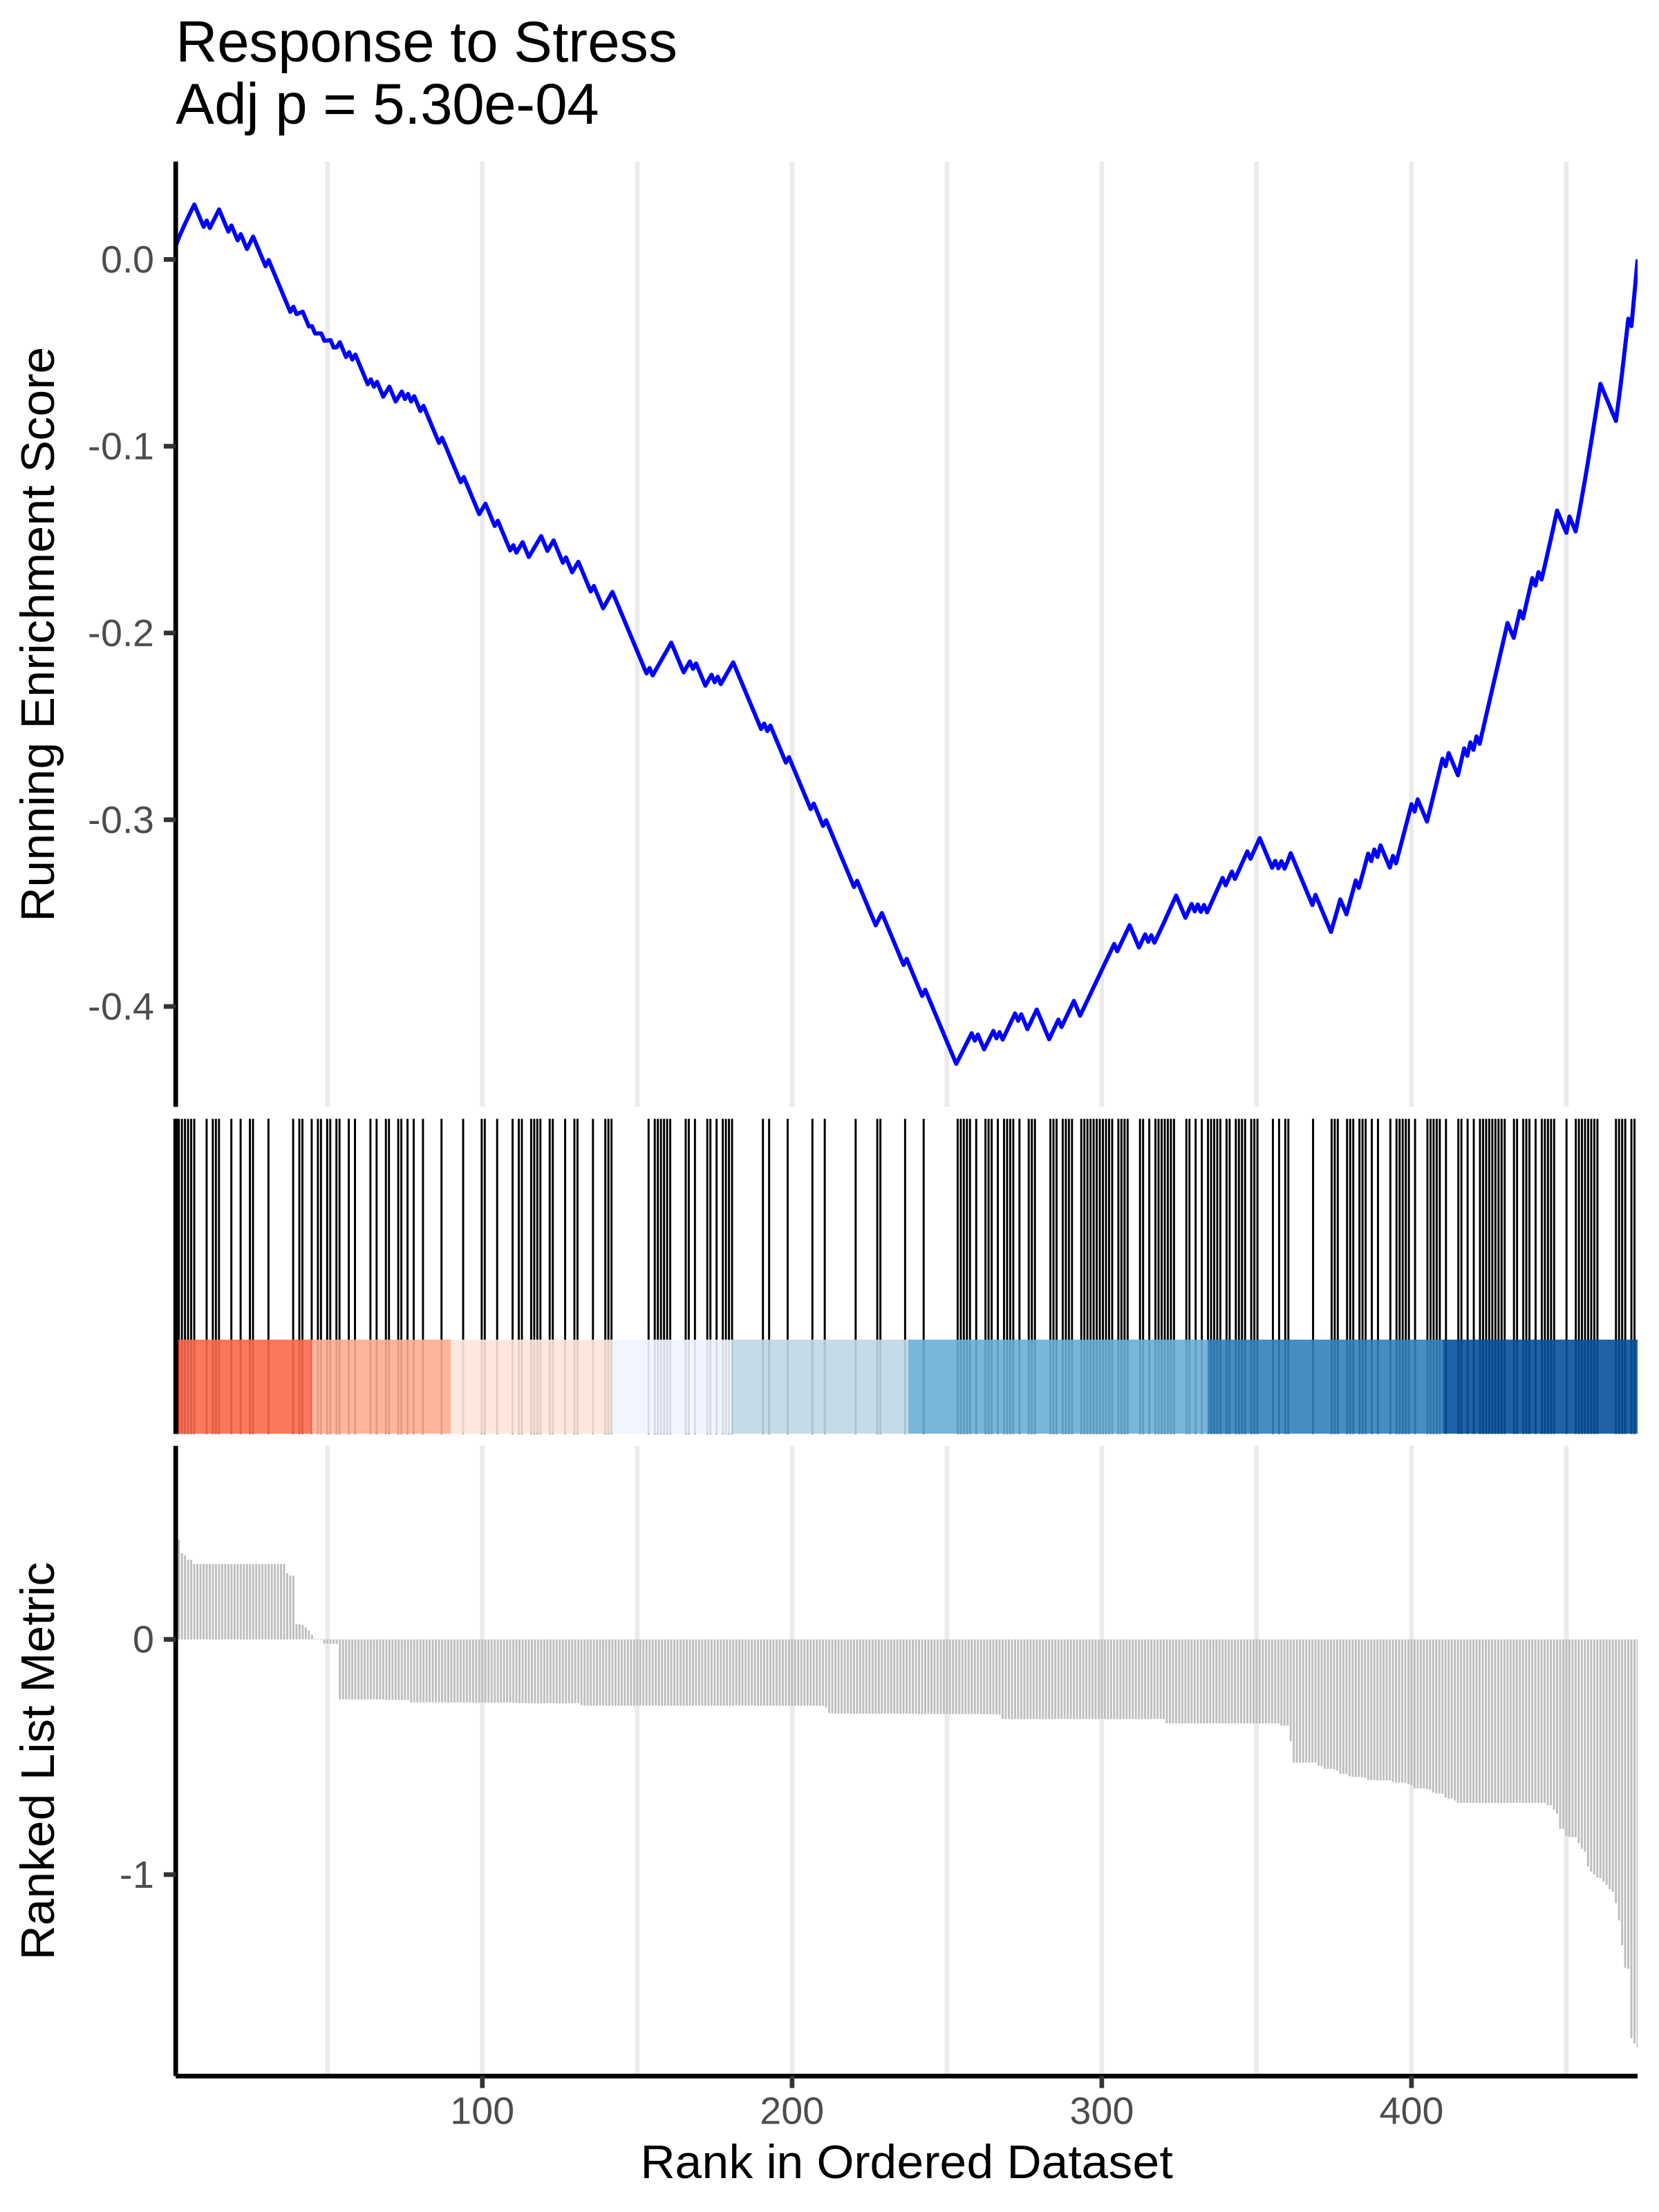

In [19]:
###############################################################################
# For PC4
###############################################################################

ordered_tf_data <- get_ordered_tfs(
  tf_corr_data = pc4_corr,
  top_n_pos    = 803,
  top_n_neg    = 803
)

set.seed(1234)
results_PC4 <- run_pc_figures_tfGSEA(
  ordered_tf_data    = ordered_tf_data,
  pc_corr            = pc4_corr,
  PC_name            = "PC4",
  axis               = "neg",
  flip_correlations  = FALSE  # set to TRUE to flip signs
)

options(repr.plot.width = 12, repr.plot.height = 16, repr.plot.res = 200)

# Get the data frame to extract info
df <- as.data.frame(results_PC4$gsea_res)


fmt_p <- function(p, digits = 2) {
  if (is.na(p))  return("NA")
  if (p == 0)    return("< 2.2e-16")   # underflow, not a true zero
  sprintf(paste0("%.", digits, "e"), p)
}

PC4_updated <- gseaplot2(
  results_PC4$gsea_res,
  geneSetID = df$ID[1],
  title = paste0(tools::toTitleCase(df$Description[1]),
                 "\nAdj p = ", fmt_p(df$p.adjust[1])),
  ES_geom = "line", color = "blue",
  base_size = 25
)
PC4_updated

In [20]:
ggsave("../../outputs/Fig4/Fig-TF-PC4-GSEA-Running_enrichment.png", PC4_updated, width = 12, height = 12, dpi = 600, create.dir = TRUE)

In [ ]:
## Done ##